# 실무 LLM: 로컬 모델(Local Models) & Prompt Engineering(프롬프트 엔지니어링)

**대상:** 사무 업무, A/S(After-Sales, 사후 서비스), 기계 엔지니어링, 설계, 조선, 해양 운영 등에서 Large Language Model(LLM, 대규모 언어 모델)을 활용해 생산성을 높이고 싶은 초보자.

**이 노트북에서 다루는 내용**

- 다양한 **현실적인 직장 시나리오**와 예시 프롬프트
- 즉시 재사용할 수 있는 **prompt engineering(프롬프트 엔지니어링)** 기법

- **Hugging Face**에서 받은 **GGUF** 파일을 **`llama-cpp-python`**(기본값)으로 로컬 LLM 호출 — 선택 백엔드: `ollama`, `transformers`, OpenAI-compatible HTTP
- **클라우드 LLM**에 대한 짧고 실용적인 소개(적용 방식과 예시 패턴)
- **단계별** 코드 셀 — 위에서 아래로 실행

> **팁:** 로컬 모델이 실행 중이 아니면 `call_llm`이 **데모 모드(demo mode)**로 폴백하므로 프롬프트 연습을 계속할 수 있습니다.


## 이 노트북 사용 방법

1. **셀을 순서대로 실행**하세요(Shift+Enter).
2. 각 코드 셀 위의 마크다운을 실행 전에 읽으세요.
3. **Step 0**에서 **`llama-cpp-python`** + **`huggingface_hub`**를 설치하고, **Step 0b**에서 **GGUF**를 다운로드하세요(기본값: Hub의 TinyLlama Q4). 노트북 기본값은 **`LLM_BACKEND=llama_cpp`**입니다. 선택: `LLM_BACKEND=ollama`(Ollama + `ollama pull` 필요), `transformers`, `openai_compatible`.
4. **클라우드** 예제는 해당 셀을 실행할 때만 API 키가 필요합니다. 그렇지 않으면 참고용으로 읽으세요.

---

## 목차

0. **llama-cpp-python** + **Hugging Face의 GGUF**(기본 경로)  
1. 환경 설정  
2. 직장 활용 사례(애플리케이션 메뉴)  
3. Prompt engineering(프롬프트 엔지니어링) 기초  
4. 로컬 LLM 헬퍼 — **`llama-cpp-python` + GGUF**(기본) 또는 선택 Ollama / transformers / HTTP + 연결 테스트  
4c. **실습:** 메뉴의 **모든** 시나리오 상세 코드(Office, A/S, Mechanical, Maritime)  
5. **프롬프트 패턴** — 마크다운 + 실행 가능한 데모(role, few-shot, steps, JSON, rubric)  
6. **빠른 연습** — 패턴 하나 + 본인 스니펫 결합(가이드 코드)  
7. **미니 연습문제** — A–D 샘플 입력(축약, 번역, UNKNOWN, 리스크 표)  
8. **클라우드 LLM** — Mermaid 흐름도 + 막대 차트(키 불필요) + 선택 OpenAI-compatible API 호출  
9. **로컬 vs 클라우드** — 의사결정 가이드 + 가중 점수 코드  
10. **한계 & 안전** — 마크다운 + 인쇄용 체크리스트 + 선택 LLM 비평  

> **실습 경로:** Step **4c** 이후 **Step 5**(패턴) → **Step 6–7**(연습 + 문제) → **Step 8**(클라우드 시각 비교)을 실행하세요.


## Step 0 — 로컬 LLM 백엔드 선택

이 워크샵은 모델을 **로컬**에서 실행하는 **두 가지** 방법을 지원합니다. 아래에서 **한 경로**를 선택하세요 — Step 4(`call_llm`)가 선택한 백엔드를 사용합니다.

| 경로 | `LLM_BACKEND` | 적합한 경우 | 설정 셀 |
|------|---------------|----------|-------------|
| **A — 노트북 내 GGUF** *(기본)* | `llama_cpp` | 자급자족: `llama-cpp-python`으로 `.gguf`를 직접 로드, 별도 서비스 불필요. | Step **0A-1**(설치) + Step **0A-2**(GGUF 다운로드). |
| **B — Ollama 서비스** | `ollama` | 이미 [Ollama](https://ollama.com)를 쓰거나, 여러 모델을 pull한 영구 로컬 모델 서버가 필요한 경우. 노트북은 `ollama_model_runner.py`(간단한 터미널 헬퍼)로 호출을 위임 — **Module 4**와 동일 패턴. | Step **0B-1**(runner 확인) + Step **0B-2**(노트북 밖 Ollama 설치) + Step **0B-3**(스모크 테스트). |

> 바로 아래 **선택 셀**이 노트북 전체의 `LLM_BACKEND` 환경 변수를 설정합니다. 선택한 경로의 셀만 실행하고 다른 경로 셀은 무시해도 됩니다.

### Path A — 설치 항목(PyPI)

- **`llama-cpp-python`** — GGUF를 로드하고 모델을 실행합니다.
- **`huggingface_hub`** — repo에서 **단일** `.gguf`를 가져오는 `hf_hub_download`.

기본적으로 Path A는 **TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF** — **`Q4_K_M`**(작고 CPU/Colab에 적합)을 다운로드합니다. Step 0A-2 실행 **전**에 환경 변수로 기본값을 덮어쓸 수 있습니다:

- **`HF_GGUF_REPO`** — 예: `bartowski/Llama-3.2-3B-Instruct-GGUF`
- **`HF_GGUF_FILE`** — 해당 repo의 정확한 파일명(예: `Llama-3.2-3B-Instruct-Q4_K_M.gguf`)
- **`HF_TOKEN`** — repo가 **gated**(접근 제한)일 때만(Hub에서 약관 수락 후)

또는 **`LLAMA_CPP_GGUF`**를 임의 `.gguf` **로컬** 경로로 설정하면 Hub 다운로드를 건너뛸 수 있습니다.

`pip`가 소스 컴파일을 시도하다 실패하면 C++ 툴체인(Windows는 **Visual Studio Build Tools** 등)을 설치하거나 공식 [llama-cpp-python installation guide](https://github.com/abetlen/llama-cpp-python#installation)의 사전 빌드 wheel(CPU / CUDA / Metal)을 따르세요.

### Path B — 설치 항목(Ollama)

- **Ollama 앱**(<https://ollama.com>에서 일회 설치)이 백그라운드 서비스로 실행.
- `ollama pull`로 하나 이상 모델 pull(예: `llama3.1:8b`, `mistral:7b`, `phi3`).
- 노트북 내부 Python 라이브러리 **`requests`** — 이 경로의 유일한 추가 Python 의존성.

Path B는 `ollama_model_runner.py`(이 폴더)로 프롬프트 파일을 Ollama HTTP API에 보내고 JSON 결과를 출력합니다. Module 4 RAG 노트북과 동일합니다. runner는 한 번에 하나 또는 여러 모델(예: `--models llama3.1:8b,mistral:7b`)을 받아 답변 비교가 쉽습니다.


In [1]:
# Step 0 — Pick the backend used by Step 4 (`call_llm`)
# Set LLM_BACKEND_CHOICE to one of: "llama_cpp" (default) or "ollama".
import os

LLM_BACKEND_CHOICE = "llama_cpp"  # change to "ollama" to use the Ollama service path

assert LLM_BACKEND_CHOICE in {"llama_cpp", "ollama"}, "Choose 'llama_cpp' or 'ollama'."
os.environ["LLM_BACKEND"] = LLM_BACKEND_CHOICE

print("LLM_BACKEND =", os.environ["LLM_BACKEND"])
if LLM_BACKEND_CHOICE == "llama_cpp":
    print("다음: Step 0A-1(설치) 및 Step 0A-2(GGUF 다운로드)를 실행하세요.")
    print("Step 0B-* 셀(Ollama 경로)은 건너뛸 수 있습니다.")
else:
    print("다음: Step 0A-* 셀은 건너뛰고 Step 0B-1 → 0B-2 → 0B-3(Ollama 경로)을 실행하세요.")
    print("팁: pull한 모델로 OLLAMA_MODEL을 설정하세요. 예: 'llama3.1:8b'.")

LLM_BACKEND = llama_cpp
다음: Step 0A-1(설치) 및 Step 0A-2(GGUF 다운로드)를 실행하세요.
Step 0B-* 셀(Ollama 경로)은 건너뛸 수 있습니다.


In [2]:
# Step 0a — Normal install: pip into THIS kernel, then verify imports
# Same from a shell (use the same Python/venv as Jupyter):
#   python -m pip install llama-cpp-python huggingface_hub

%pip install -q llama-cpp-python huggingface_hub

import llama_cpp  # noqa: F401
import huggingface_hub  # noqa: F401

print("설정 완료 — llama-cpp-python과 huggingface_hub가 이 커널에 설치되었습니다.")
print(
    "다음: Step 0b가 Hugging Face에서 기본 GGUF를 다운로드하거나, "
    "LLAMA_CPP_GGUF를 로컬 .gguf 경로로 설정해 0b를 건너뛸 수 있습니다."
)


Note: you may need to restart the kernel to use updated packages.
설정 완료 — llama-cpp-python과 huggingface_hub가 이 커널에 설치되었습니다.
다음: Step 0b가 Hugging Face에서 기본 GGUF를 다운로드하거나, LLAMA_CPP_GGUF를 로컬 .gguf 경로로 설정해 0b를 건너뛸 수 있습니다.


In [3]:
# Step 0b — Download default GGUF from Hugging Face (large download on first run)
import os

from huggingface_hub import hf_hub_download

# Defaults: small instruct chat model, Q4_K_M — override via env before running this cell
HF_GGUF_REPO = os.environ.get(
    "HF_GGUF_REPO", "TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF"
).strip()
HF_GGUF_FILE = os.environ.get(
    "HF_GGUF_FILE", "tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf"
).strip()
_HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")

_existing = (os.environ.get("LLAMA_CPP_GGUF") or "").strip()
if _existing and os.path.isfile(_existing):
    print("기존 LLAMA_CPP_GGUF 사용 — 다운로드 건너뜀:", _existing)
else:
    print(f"Hub에서 다운로드: {HF_GGUF_REPO} / {HF_GGUF_FILE} ...")
    path = hf_hub_download(
        repo_id=HF_GGUF_REPO, filename=HF_GGUF_FILE, token=_HF_TOKEN
    )
    os.environ["LLAMA_CPP_GGUF"] = path
    print("LLAMA_CPP_GGUF 설정:", path)

print("완료. Step 1로 진행한 뒤 Step 4를 순서대로 실행하세요.")


Hub에서 다운로드: TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF / tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf ...
LLAMA_CPP_GGUF 설정: /home/ethan/.cache/huggingface/hub/models--TheBloke--TinyLlama-1.1B-Chat-v1.0-GGUF/snapshots/52e7645ba7c309695bec7ac98f4f005b139cf465/tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf
완료. Step 1로 진행한 뒤 Step 4를 순서대로 실행하세요.


## Step 0B — Ollama 경로(`llama_cpp`를 선택했다면 건너뛰기)

위 선택 셀이 `LLM_BACKEND_CHOICE = "ollama"`로 설정한 경우에만 **0B-\*** 셀을 실행하세요.

노트북은 프롬프트를 Python에 유지하지만 실제 호출은 작은 터미널 스크립트 `ollama_model_runner.py`(**Module 4**에서 본 파일과 동일)에 위임합니다. Jupyter 커널 안에서 LLM 서비스를 돌리는 것보다 안정적입니다:

1. Ollama는 **영구 백그라운드 서비스**(`ollama serve`)입니다. 커널을 재시작해도 Ollama는 재시작되지 않습니다.
2. 스크립트는 UTF-8 텍스트 파일에서 프롬프트를 읽고 **하나 또는 여러** 모델(`--models llama3.1:8b,mistral:7b`)을 받습니다. 단일 JSON 문서를 출력해 노트북이 파싱/비교할 수 있습니다.
3. `OLLAMA_MODEL`만 바꾸면 노트북 코드를 수정하지 않고 모델을 교체할 수 있습니다.

필요한 것:

- 이 노트북 내부 **`requests`** Python 라이브러리(**Step 0B-1**에서 설치).
- **Ollama 서비스** + pull된 모델 최소 하나(**Step 0B-2**에서 수동 설치).
- runner 스크립트 **스모크 테스트** 통과(**Step 0B-3**).

0B-3이 성공하면 선택 셀이 `LLM_BACKEND=ollama`를 설정했으므로 Step 4의 `call_llm`이 자동으로 `ollama_generate` 헬퍼(`http://localhost:11434/api/generate`에 POST)로 디스패치합니다.


In [4]:
# Step 0B-1 — Ollama path · install the lightweight client and check the runner script
# Only `requests` is needed inside the notebook; everything else lives in the Ollama service.

%pip install -q requests

from pathlib import Path

runner_path = Path("ollama_model_runner.py")
print("Runner 존재:", runner_path.exists())
print("Runner 경로 :", runner_path.resolve())

if not runner_path.exists():
    raise FileNotFoundError(
        "ollama_model_runner.py not found in the current folder. "
        "Open this notebook from the Module_4 directory (where the .py helper lives)."
    )

print("준비 완료 — Step 0B-2(수동 Ollama 설치) 및 Step 0B-3(스모크 테스트)를 진행하세요.")

Note: you may need to restart the kernel to use updated packages.
Runner 존재: True
Runner 경로 : /home/ethan/newgen/KMOU_Course/Module_4/ollama_model_runner.py
준비 완료 — Step 0B-2(수동 Ollama 설치) 및 Step 0B-3(스모크 테스트)를 진행하세요.


### Step 0B-2 — Ollama 설치 및 모델 pull(수동, 노트북 밖)

일반 **터미널**에서 실행하세요. 노트북 세션마다가 아니라 **머신당 한 번**이면 됩니다.

**Ollama 설치**

- **Linux**
  ```bash
  curl -fsSL https://ollama.com/install.sh | sh
  ```
- **macOS**
  ```bash
  brew install ollama
  # or download the installer from https://ollama.com/download
  ```
- **Windows**: <https://ollama.com/download>에서 설치 프로그램을 받아 실행.

**서비스 시작 및 모델 pull**

```bash
ollama serve            # keep this terminal open (or use the system service)
ollama pull llama3.1:8b # ~4.7 GB. Lighter options: phi3, qwen2.5:3b, mistral:7b
ollama list             # confirm the model is available
```

노트북 밖에서 하는 이유:

- Ollama는 영구 서비스 프로세스이고, 노트북 커널은 재시작되며 커널 내 서비스는 종료됩니다.
- 외부 서비스 + 얇은 클라이언트 스크립트가 반복 실험과 모델 비교에 더 안정적입니다.

`ollama list`에 원하는 모델이 보이면 `OLLAMA_MODEL`을 해당 태그(아래 기본값 `llama3.1:8b`)로 설정하고 Step 0B-3으로 진행하세요.

If ```ollama serve ``` not working, run python 


In [5]:
# Step 0B-3 — Ollama path · sanity-check the service through the terminal runner
# This proves the Ollama service AND ollama_model_runner.py round-trip work BEFORE
# Step 4's call_llm() uses them. It mirrors Section B of Module 4's RAG notebook.

import json
import os
import subprocess
import sys
import tempfile

OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "llama3.1:8b")  # must match an `ollama pull`-ed model

smoke_prompt = (
    "Reply with exactly one short sentence: what is prompt engineering for LLMs?"
)

prompt_file = tempfile.NamedTemporaryFile(
    mode="w", suffix=".txt", delete=False, encoding="utf-8"
)
prompt_file.write(smoke_prompt)
prompt_file.flush()
prompt_file.close()

cmd = [
    sys.executable,
    "ollama_model_runner.py",
    "--host", OLLAMA_HOST,
    "--models", OLLAMA_MODEL,
    "--prompt-file", prompt_file.name,
    "--temperature", "0.1",
    "--max-tokens", "1000",
]

print("명령 미리보기:")
print(" ".join(cmd))

run = subprocess.run(cmd, capture_output=True, text=True)
print("\n반환 코드:", run.returncode)
if run.stderr.strip():
    print("\n--- STDERR (처음 600자) ---")
    print(run.stderr[:600])

try:
    payload = json.loads(run.stdout)
    first = payload["outputs"][0]
    print("\n모델   :", first.get("model"))
    print("상태  :", first.get("status"))
    print("응답:", (first.get("response") or "").strip())
except Exception as exc:
    print("\nJSON 출력을 파싱할 수 없습니다:", exc)
    print("원시 stdout (처음 600자):")
    print(run.stdout[:600])
    print(
        "\n문제 해결: `ollama serve`가 실행 중인가요? `ollama list`에 "
        f"{OLLAMA_MODEL!r}? `ollama pull {OLLAMA_MODEL}`를 실행했나요?"
    )

명령 미리보기:
/home/ethan/anaconda3/envs/kmouc/bin/python ollama_model_runner.py --host http://localhost:11434 --models llama3.1:8b --prompt-file /tmp/tmpijhq1sxv.txt --temperature 0.1 --max-tokens 1000

반환 코드: 0

모델   : llama3.1:8b
상태  : ok
응답: Prompt engineering for LLMs involves designing and crafting input prompts to elicit specific, accurate, and relevant responses from large language models.


## Step 1 — 환경 설정

사용 패키지:

- **`llama-cpp-python`** + **`huggingface_hub`** — 기본 로컬 추론(GGUF); Step 0a에서 설치(`%pip` 또는 커널 env의 동일 `pip`)  
- **`requests`** — 선택 백엔드: **Ollama**(`/api/generate`) 또는 OpenAI-compatible HTTP  
- **`python-dotenv`**(선택) — `.env` 로드(예: `LLAMA_CPP_GGUF`, `OLLAMA_HOST`, `HF_TOKEN`)  
- **`json`** — 구조화 출력  

**선택** `LLM_BACKEND=transformers`일 때: `torch`, `transformers`, `accelerate`.

**아래 셀을 한 번 실행**하세요. 필요하면 `pip install` 주석을 해제하세요.


In [6]:
# Uncomment and run once if needed:
# %pip install -q requests python-dotenv
# llama-cpp + Hub are installed in Step 0a; if you skipped it, uncomment:
# %pip install -q llama-cpp-python huggingface_hub
# Optional for LLM_BACKEND=transformers:
# %pip install -q torch transformers accelerate sentencepiece safetensors

import json
import os
import textwrap
from typing import Any, Dict, List, Optional

import requests

try:
    from pathlib import Path

    from dotenv import load_dotenv

    for env_dir in (Path.cwd(), Path.cwd().parent):
        env_path = env_dir / ".env"
        if env_path.is_file():
            load_dotenv(env_path)
            break
    else:
        load_dotenv()
except Exception:
    pass

print("설정 완료 — 라이브러리를 import했습니다.")


설정 완료 — 라이브러리를 import했습니다.


## Step 2 — 직장 활용 사례(다양한 예시)

아래는 **애플리케이션 메뉴**입니다. 첫날 모두 할 필요는 없습니다 — 업무에 맞는 2–3개를 고르세요.

### 사무 & 행정(Office & administration)

| 시나리오 | LLM이 돕는 일 | 예시 지시문 |
|----------|---------------------------|---------------------|
| 이메일 & 보고서 | 초안, 축약, 어조 변경 | “Rewrite this email to be polite but firm.” |
| 회의록 | 조치 항목·담당자 요약 | “Extract decisions and action items.” |
| 스프레드시트 | 수식 설명, 검증 제안 | “Explain this formula in plain language.” |
| 프레젠테이션 | 슬라이드 개요, 발표자 노트 | “Create a 5-slide outline for topic X.” |
| 정책 / 컴플라이언스 | 1차 체크리스트 | “List risks if we skip step Y.” |

### A/S(After-Sales) & 고객 지원

| 시나리오 | 예시 |
|----------|---------|
| 티켓 분류(triage) | 고객 문의에서 긴급도 분류 |
| 1차 답변 초안 | 정중한 확인 + 시리얼 번호 요청 |
| 지식 베이스 | 불릿 노트를 FAQ 답변으로 |
| 인수인계 요약 | 다음 근무조를 위한 “시도한 내용” |

### 기계 엔지니어링 & 설계

| 시나리오 | 예시 |
|----------|---------|
| 요구사항 → spec 개요 | 이해관계자 불릿을 구조화된 spec으로 |
| 설계 검토 준비 | 공차, 재료, 인터페이스 관련 질문 목록 |
| 고장 보고서 | 거친 메모에서 “5 Whys” 초안 정리 |
| BOM / 변경 노트 | 부품 대체 영향 요약 |
| 표준 문구 | 운영자를 위한 표준 단락 단순화 |

### 조선 & 해양(예시)

| 시나리오 | 예시 |
|----------|---------|
| 작업 패키지 설명 | 야드 전문 용어를 명확한 작업 브리프로 |
| 안전 / 허가 문구 | 작업 방법서 초안에서 체크리스트 |
| 벤더 서신 | 지연·사양 충돌에 대한 중립 이메일 |
| 선급 / 검사 준비 | 검사에 일반적으로 필요한 문서 목록 |
| 로그 요약 | 불릿 포인트에서 일일 보고서 |

**실습 코드:** Step **4c**(이 노트북 뒤쪽, Step **4**가 `call_llm`을 정의한 후)가 위 표 **각 행**을 **샘플 데이터 → 프롬프트 → `call_llm`**으로 작은 셀에 나눠 진행합니다.

**중요:** LLM은 기술 사실(압력, 규정, 토크 값 등)을 **환각(hallucinate)**할 수 있습니다. 매뉴얼, 선급 규칙, 승인 도면으로 **항상 검증**하세요.


### Step 2 코드 — 메뉴를 구조화된 카탈로그로

위 표는 읽기에 편하지만 실무에서는 보통 **동일 정보를 Python**으로 두어:

- 부서별 필터(Office만 또는 Maritime만).
- **태그**별 필터(예: 부서 전체의 "checklist" 스타일 시나리오).
- 예시 지시문을 **Step 4c** 시드 프롬프트로 재사용.

아래 셀은 작은 `UseCase` dataclass와 `USE_CASES` 리스트를 정의한 뒤 pandas DataFrame으로 렌더링합니다.

> 여기서는 아직 LLM을 **호출하지 않습니다**. Step 4에서 연결 — Step 2는 *어떤* 시나리오에 집중할지 정하는 단계입니다.


In [7]:
# Step 2 code — Build a structured catalog of the use cases shown in the tables above.
from dataclasses import dataclass, asdict
from typing import List, Tuple

import pandas as pd


@dataclass(frozen=True)
class UseCase:
    department: str
    scenario: str
    llm_helps_with: str
    example_instruction: str
    tags: Tuple[str, ...] = ()


USE_CASES: List[UseCase] = [
    # --- Office & administration ---
    UseCase("Office", "Email & reports", "Draft, shorten, change tone",
            "Rewrite this email to be polite but firm.", ("draft", "rewrite")),
    UseCase("Office", "Meeting notes", "Summarize actions & owners",
            "Extract decisions and action items from these notes.", ("extract", "summarize")),
    UseCase("Office", "Spreadsheets", "Explain formulas, suggest checks",
            "Explain this formula in plain language.", ("explain",)),
    UseCase("Office", "Presentations", "Outline slides, speaker notes",
            "Create a 5-slide outline for topic X.", ("draft",)),
    UseCase("Office", "Policy / compliance", "First-pass risk checklist",
            "List operational risks if step Y is skipped.", ("checklist", "risk")),
    # --- After-sales (A/S) ---
    UseCase("After-sales", "Ticket triage", "Classify urgency from customer text",
            "Classify this ticket: severity, category, next step.", ("classify",)),
    UseCase("After-sales", "First reply draft", "Polite acknowledgment + ask for data",
            "Draft a first reply asking for serial number and error code.", ("draft",)),
    UseCase("After-sales", "Knowledge base", "Bullets → FAQ answer",
            "Turn these engineering bullets into a customer-facing FAQ.", ("rewrite",)),
    UseCase("After-sales", "Handover summary", "What was tried for the next shift",
            "Write a handover note for the next support shift.", ("summarize",)),
    # --- Mechanical engineering & design ---
    UseCase("Mechanical", "Requirements → spec outline", "Stakeholder bullets → structured spec",
            "Convert these bullets into a structured spec outline.", ("structure",)),
    UseCase("Mechanical", "Design review prep", "Questions about tolerances / materials",
            "List review questions grouped by topic.", ("checklist",)),
    UseCase("Mechanical", "Failure report", "Clarify a 5-Whys draft",
            "Organize these rough notes into a 5 Whys analysis.", ("structure",)),
    UseCase("Mechanical", "BOM / change notes", "Impact of a part substitution",
            "Summarize the impact of substituting part A with part B.", ("summarize",)),
    UseCase("Mechanical", "Standards language", "Simplify a standard paragraph",
            "Explain this dense paragraph for operators.", ("rewrite", "explain")),
    # --- Shipbuilding & maritime ---
    UseCase("Maritime", "Work package description", "Yard jargon → clear task brief",
            "Turn this work package text into a clear task brief.", ("rewrite",)),
    UseCase("Maritime", "Safety / permit text", "Checklist from a method statement",
            "Build a permit checklist from this method statement.", ("checklist",)),
    UseCase("Maritime", "Vendor correspondence", "Neutral email about delay / spec clash",
            "Draft a neutral vendor email about a delay.", ("draft",)),
    UseCase("Maritime", "Class / survey prep", "Typical document list for an inspection",
            "List documents typically required for this survey.", ("checklist",)),
    UseCase("Maritime", "Log summaries", "Daily report from bullet points",
            "Write a daily log from these bullet notes.", ("summarize",)),
]

use_cases_df = pd.DataFrame([asdict(uc) for uc in USE_CASES])
print(
    f"로드됨 {len(use_cases_df)}개 use case, "
    f"{use_cases_df['department'].nunique()}개 부서."
)
print("\n부서별 개수:")
print(use_cases_df["department"].value_counts())

use_cases_df.head(10)

로드됨 19개 use case, 4개 부서.

부서별 개수:
department
Office         5
Mechanical     5
Maritime       5
After-sales    4
Name: count, dtype: int64


,department,scenario,llm_helps_with,example_instruction,tags
0,Office,Email & reports,"Draft, shorten, change tone",Rewrite this email to be polite but firm.,"(draft, rewrite)"
1,Office,Meeting notes,Summarize actions & owners,Extract decisions and action items from these ...,"(extract, summarize)"
2,Office,Spreadsheets,"Explain formulas, suggest checks",Explain this formula in plain language.,"(explain,)"
3,Office,Presentations,"Outline slides, speaker notes",Create a 5-slide outline for topic X.,"(draft,)"
4,Office,Policy / compliance,First-pass risk checklist,List operational risks if step Y is skipped.,"(checklist, risk)"
5,After-sales,Ticket triage,Classify urgency from customer text,"Classify this ticket: severity, category, next...","(classify,)"
6,After-sales,First reply draft,Polite acknowledgment + ask for data,Draft a first reply asking for serial number a...,"(draft,)"
7,After-sales,Knowledge base,Bullets → FAQ answer,Turn these engineering bullets into a customer...,"(rewrite,)"
8,After-sales,Handover summary,What was tried for the next shift,Write a handover note for the next support shift.,"(summarize,)"
9,Mechanical,Requirements → spec outline,Stakeholder bullets → structured spec,Convert these bullets into a structured spec o...,"(structure,)"


#### 부서별 탐색 또는 단일 시나리오 선택

두 개의 작은 헬퍼가 노트북에서 카탈로그 탐색을 쉽게 합니다:

- **`filter_use_cases(department=..., tag=...)`** — 조건에 맞는 행만 DataFrame으로 반환. 인자 하나 또는 둘 다 전달.
- **`show_use_case(index)`** — 한 use case를 보기 좋게 출력(Step 4c에 가져올 시나리오 결정 시 유용).

셀 실행 후 다음이 보여야 합니다:

1. 모든 Maritime 행.
2. `"checklist"` 태그 시나리오(부서 전체).
3. `USE_CASES[0]`의 예시 지시문을 확인할 수 있는 출력.


In [8]:
# Step 2 code — Filter and inspect the catalog.
from typing import Optional

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]


def filter_use_cases(
    department: Optional[str] = None,
    tag: Optional[str] = None,
) -> pd.DataFrame:
    """Return a copy of use_cases_df filtered by department and/or tag (case-insensitive)."""
    df = use_cases_df.copy()
    if department:
        df = df[df["department"].str.lower() == department.lower()]
    if tag:
        wanted = tag.lower()
        df = df[df["tags"].apply(lambda ts: wanted in [t.lower() for t in ts])]
    return df.reset_index(drop=True)


def show_use_case(index: int) -> None:
    """Pretty-print a single use case from the catalog."""
    row = use_cases_df.iloc[index]
    print(f"[{row['department']}] {row['scenario']}")
    print("-" * 60)
    print("LLM 활용     :", row["llm_helps_with"])
    print("예시 지시문:", row["example_instruction"])
    print("태그               :", ", ".join(row["tags"]) or "—")


print(">>> 1) 모든 Maritime 시나리오")
display(filter_use_cases(department="Maritime"))

print("\n>>> 2) 'checklist' 태그 시나리오(부서 전체)")
display(filter_use_cases(tag="checklist"))

print("\n>>> 3) 단일 use case 검사(인덱스 0)")
show_use_case(0)

>>> 1) 모든 Maritime 시나리오


,department,scenario,llm_helps_with,example_instruction,tags
0,Maritime,Work package description,Yard jargon → clear task brief,Turn this work package text into a clear task ...,"(rewrite,)"
1,Maritime,Safety / permit text,Checklist from a method statement,Build a permit checklist from this method stat...,"(checklist,)"
2,Maritime,Vendor correspondence,Neutral email about delay / spec clash,Draft a neutral vendor email about a delay.,"(draft,)"
3,Maritime,Class / survey prep,Typical document list for an inspection,List documents typically required for this sur...,"(checklist,)"
4,Maritime,Log summaries,Daily report from bullet points,Write a daily log from these bullet notes.,"(summarize,)"



>>> 2) 'checklist' 태그 시나리오(부서 전체)


,department,scenario,llm_helps_with,example_instruction,tags
0,Office,Policy / compliance,First-pass risk checklist,List operational risks if step Y is skipped.,"(checklist, risk)"
1,Mechanical,Design review prep,Questions about tolerances / materials,List review questions grouped by topic.,"(checklist,)"
2,Maritime,Safety / permit text,Checklist from a method statement,Build a permit checklist from this method stat...,"(checklist,)"
3,Maritime,Class / survey prep,Typical document list for an inspection,List documents typically required for this sur...,"(checklist,)"



>>> 3) 단일 use case 검사(인덱스 0)
[Office] Email & reports
------------------------------------------------------------
LLM 활용     : Draft, shorten, change tone
예시 지시문: Rewrite this email to be polite but firm.
태그               : draft, rewrite


## Step 3 — Prompt engineering(프롬프트 엔지니어링) 기초

**Prompt engineering**은 모델을 재학습하지 않고도 필요한 방식으로 동작하도록 지시문을 작성하는 것입니다.

### 핵심 아이디어

1. **구체적으로:** 대상, 형식, 길이, 제약을 명시(“max 150 words”, “bullets only”).
2. **맥락 제공:** “어제 이메일”이 아니라 정확한 단락, 티켓, 요구사항을 붙여넣기.
3. **출력 정의:** JSON, 표, 번호 단계, 제목 줄이 있는 이메일 등.
4. **역할 / 페르소나(신중히):** “You are a technical writer”는 어조 개선에 도움; 사실은 여전히 검증.
5. **Few-shot 예시:** 형식이 중요할 때 입력/출력 쌍 1–3개 제시.
6. **반복:** 답이 모호하면 제약을 추가하거나 “missing information”을 명시적으로 요청.

### 간단 용어집

- **System prompt** — 상위 규칙(일부 API는 “user” 메시지와 분리).
- **Zero-shot** — 예시 없이 지시만.
- **Few-shot** — 지시 + 짧은 예시.
- **Chain-of-thought** — 단계별 추론 요청(체크리스트에 유용; 결과는 검증).


### Step 3 코드 — 재사용 가능한 프롬프트 빌더

위 “핵심 아이디어”(구체성, 맥락, 출력 정의 등)는 프롬프트에 **라벨된 섹션**으로 두면 적용이 쉽습니다. 아래 헬퍼 `build_prompt(...)`가 선택 섹션으로 프롬프트를 조립합니다:

| 섹션 | 역할 | “핵심 아이디어” 매핑 |
|---------|--------------|------------------------|
| `role` | 페르소나 / 관점 설정 | Role / persona |
| `context` | 원본 자료 붙여넣기 | Give context |
| `instruction` (필수) | 실제 작업 | Be specific |
| `constraints` | 길이·어조·unknown 처리 등 강한 규칙 | Be specific |
| `output_format` | 구체적 형태(markdown 골격, JSON 키, 표 헤더) | Define the output |
| `examples` | Few-shot 입력/출력 쌍 | Few-shot examples |

아래 셀은 **동일 목표**의 두 프롬프트를 비교합니다:

1. **모호한** 프롬프트(`"Summarize this meeting."`) — 모든 규칙 위반.
2. **구체적인** 프롬프트 — 섹션별 구성으로 모델이 정확히 무엇을 낼지 알 수 있음.

아직 모델을 **호출하지 않습니다** — 전송될 텍스트만 검사합니다. Step 4에 도달하면 `print(specific_prompt)`를 `call_llm(specific_prompt)`로 바꿔 출력 개선을 확인할 수 있습니다.


In [9]:
# Step 3 code — A small helper that *builds* a structured prompt.
# We do NOT call an LLM yet (Step 4 wires that up). The point is to see how
# the "core ideas" above translate into concrete text the model receives.
from textwrap import dedent
from typing import List, Optional, Sequence, Tuple


def build_prompt(
    instruction: str,
    *,
    role: Optional[str] = None,
    context: Optional[str] = None,
    constraints: Optional[Sequence[str]] = None,
    output_format: Optional[str] = None,
    examples: Optional[Sequence[Tuple[str, str]]] = None,
) -> str:
    """Assemble a structured prompt from labelled sections.

    Sections appear only when provided. ``examples`` is a sequence of
    ``(input, expected_output)`` pairs — the same shape Step 5.2 uses.
    """
    parts: List[str] = []
    if role:
        parts.append(f"ROLE:\n{role.strip()}")
    if context:
        parts.append(f"CONTEXT:\n{context.strip()}")
    parts.append(f"INSTRUCTION:\n{instruction.strip()}")
    if constraints:
        bullets = "\n".join(f"- {c.strip()}" for c in constraints)
        parts.append(f"CONSTRAINTS:\n{bullets}")
    if output_format:
        parts.append(f"OUTPUT FORMAT:\n{output_format.strip()}")
    if examples:
        blocks = []
        for i, (inp, out) in enumerate(examples, start=1):
            blocks.append(
                f"Example {i} input:\n{inp.strip()}\n\nExample {i} output:\n{out.strip()}"
            )
        parts.append("EXAMPLES:\n" + "\n\n".join(blocks))
    return "\n\n".join(parts)


vague_prompt = "Summarize this meeting."

specific_prompt = build_prompt(
    role="You are an assistant for a shipyard planning team.",
    context=(
        "We held a 30-minute coordination meeting about delayed insulation work. "
        "Attendees: planning, QA, and a supplier representative. The supplier "
        "confirmed a 2-day delay on insulation panel delivery."
    ),
    instruction=(
        "Summarize the meeting for someone who could not attend, focusing on "
        "decisions taken and open questions."
    ),
    output_format=dedent(
        """
        ## Decisions
        - …

        ## Open questions
        - …

        ## Action items
        | Owner | Action | Due |
        """
    ),
    constraints=[
        "Maximum 150 words.",
        "Use only information given in the context — write UNKNOWN otherwise.",
        "Do not invent owner names or deadlines.",
    ],
)

print("--- 모호한 프롬프트 (출력이 나쁠 가능성) ---")
print(vague_prompt)
print(f"(길이: {len(vague_prompt)} 자)")

print("\n--- 구체적 프롬프트 (동일 목표, 완전 지정) ---")
print(specific_prompt)
print(f"(길이: {len(specific_prompt)} 자)")

--- 모호한 프롬프트 (출력이 나쁠 가능성) ---
Summarize this meeting.
(길이: 23 자)

--- 구체적 프롬프트 (동일 목표, 완전 지정) ---
ROLE:
You are an assistant for a shipyard planning team.

CONTEXT:
We held a 30-minute coordination meeting about delayed insulation work. Attendees: planning, QA, and a supplier representative. The supplier confirmed a 2-day delay on insulation panel delivery.

INSTRUCTION:
Summarize the meeting for someone who could not attend, focusing on decisions taken and open questions.

CONSTRAINTS:
- Maximum 150 words.
- Use only information given in the context — write UNKNOWN otherwise.
- Do not invent owner names or deadlines.

OUTPUT FORMAT:
## Decisions
- …

## Open questions
- …

## Action items
| Owner | Action | Due |
(길이: 625 자)


### Step 3 코드 — Zero-shot vs few-shot

동일 `build_prompt` 헬퍼가 **few-shot 예시** — 원하는 형태를 보여 주는 `(input, output)` 쌍 — 를 지원합니다. 다음 경우에 사용하세요:

- 원하는 출력 형식을 말로 설명하기 어려울 때(커스텀 라벨, JSON 키, 어조).
- Zero-shot이 **대체로 맞지만 형태가 들쭉날쭉**할 때.
- 많은 호출에서 안정적 구조가 필요할 때(예: 대시보드용 티켓 triage).

**동일** 지원 티켓 작업에 대해 두 프롬프트를 만듭니다:

1. **Zero-shot** — 지시 + 출력 형식만.
2. **Few-shot** — 동일 프롬프트 + 두 개 예시(`P1 hardware`, `P3 software`).

둘 다 검토하세요. Few-shot은 더 길지만 키 이름·심각도 표현에서 모델이 벗어날 여지가 훨씬 적습니다.


In [10]:
# Step 3 code — Same build_prompt helper, now with few-shot examples for ticket triage.
# `build_prompt` was defined in the previous Step 3 code cell — run that one first.

triage_examples = [
    (
        "Customer: pump leaks oil; production halted; we lose 5k EUR/hour.",
        '{"severity": "P1", "category": "hardware", "next_step": "dispatch field technician within 4h"}',
    ),
    (
        "Customer: dashboard chart loads slowly after the update; no outage.",
        '{"severity": "P3", "category": "software", "next_step": "reproduce, log, schedule patch"}',
    ),
]

new_ticket = (
    "Ticket: HVAC controller resets every 4 hours on board; chief engineer "
    "requesting urgent help. No alarms persistent. Vessel at sea, next port in 2 days."
)

triage_format = (
    '{"severity": "P1|P2|P3|P4", '
    '"category": "hardware|software|process|unknown", '
    '"next_step": "<one sentence>"}'
)

triage_constraints = [
    "Return ONLY valid JSON — no prose, no markdown fence.",
    "Use UNKNOWN-style values rather than guessing missing facts.",
]

zero_shot_prompt = build_prompt(
    instruction="Classify the support ticket below and return JSON.",
    context=new_ticket,
    constraints=triage_constraints,
    output_format=triage_format,
)

few_shot_prompt = build_prompt(
    instruction="Classify the support ticket below and return JSON.",
    context=new_ticket,
    constraints=triage_constraints,
    output_format=triage_format,
    examples=triage_examples,
)

print("--- Zero-shot 프롬프트 ---")
print(zero_shot_prompt)
print(f"(길이: {len(zero_shot_prompt)} 자)")

print("\n--- Few-shot 프롬프트 (동일 작업, 예시 2개) ---")
print(few_shot_prompt)
print(f"(길이: {len(few_shot_prompt)} 자)")

--- Zero-shot 프롬프트 ---
CONTEXT:
Ticket: HVAC controller resets every 4 hours on board; chief engineer requesting urgent help. No alarms persistent. Vessel at sea, next port in 2 days.

INSTRUCTION:
Classify the support ticket below and return JSON.

CONSTRAINTS:
- Return ONLY valid JSON — no prose, no markdown fence.
- Use UNKNOWN-style values rather than guessing missing facts.

OUTPUT FORMAT:
{"severity": "P1|P2|P3|P4", "category": "hardware|software|process|unknown", "next_step": "<one sentence>"}
(길이: 482 자)

--- Few-shot 프롬프트 (동일 작업, 예시 2개) ---
CONTEXT:
Ticket: HVAC controller resets every 4 hours on board; chief engineer requesting urgent help. No alarms persistent. Vessel at sea, next port in 2 days.

INSTRUCTION:
Classify the support ticket below and return JSON.

CONSTRAINTS:
- Return ONLY valid JSON — no prose, no markdown fence.
- Use UNKNOWN-style values rather than guessing missing facts.

OUTPUT FORMAT:
{"severity": "P1|P2|P3|P4", "category": "hardware|software|process|un

## Step 4 — 재사용 헬퍼: `call_llm` (**llama-cpp-python** + **Hugging Face의 GGUF**)

### 기본: **llama-cpp-python** (GGUF)

- **`LLM_BACKEND=llama_cpp`**(기본)은 `llama-cpp-python`으로 **`.gguf`** 파일을 로드합니다.  
- **`LLAMA_CPP_GGUF`**를 **로컬 경로**로 설정하거나 Step **0b** / env **`HF_GGUF_REPO`** + **`HF_GGUF_FILE`**로 첫 사용 시 Hub에서 자동 다운로드.  
- 기본값은 Step 0b와 동일: **TheBloke/TinyLlama** Q4_K_M(CPU / 제한 RAM에 적합). GPU/RAM이 있으면 **`HF_GGUF_*`**로 더 큰 instruct 모델로 교체.  
- 선택 튜닝: **`LLAMA_CPP_N_CTX`**(기본 `4096`), **`LLAMA_CPP_N_GPU_LAYERS`**(기본 `0` = CPU만).

### 기타 백엔드(`LLM_BACKEND`)

| 값 | 사용 시점 |
|-------|-------------|
| **`llama_cpp`** (기본) | **GGUF** + `llama-cpp-python` — Step 0 참고 |
| `ollama` | [Ollama](https://ollama.com) HTTP API; `OLLAMA_MODEL` 설정(예: `llama3.2`) 및 `ollama pull` |
| `transformers` | Hugging Face `transformers` + PyTorch; `TRANSFORMERS_MODEL_ID`, gated 모델은 선택 `HF_TOKEN` |
| `openai_compatible` | `LOCAL_LLM_BASE_URL`의 LM Studio / OpenAI-compatible 서버 |

---

Step 4는 여덟 개의 짧은 하위 단계로 나뉩니다. 각 코드 셀 위 마크다운을 실행 전에 읽으세요:

| 하위 단계 | 정의 내용 |
|----------|-----------------|
| **Step 4.1** | import 및 공유 설정(env vars, lazy cache) |
| **Step 4.2** | Backend A · `llama_cpp`(기본, 프로세스 내 GGUF) |
| **Step 4.3** | Backend B · `ollama`(HTTP 서비스, `LLM_BACKEND=ollama`) |
| **Step 4.4** | Backend C · `transformers`(선택, 프로세스 내 PyTorch) |
| **Step 4.5** | Backend D · `openai_compatible`(LM Studio / vLLM / llama.cpp server) |
| **Step 4.6** | `call_llm` 디스패처 + DEMO MODE 폴백 |
| **Step 4.7** | 표시 헬퍼(`show`, `display_llm_result`) |
| **Step 4.8** | 활성 백엔드 확인 로그 |

항상 **4.1**, **4.6**, **4.7**, **4.8**과 Step 0 선택에 맞는 **백엔드 셀 하나**가 필요합니다. 다른 백엔드 셀은 참고용으로 실행해도 안전합니다(함수만 정의).



### Step 4.1 — Import 및 공유 설정

백엔드 헬퍼 정의 전, 다음 코드 셀이 다음을 설정합니다:

- **Import**: `os`, `requests`, `textwrap`, `html`, 및 선택 `IPython.display` 폴백( Jupyter 밖 일반 Python에서도 동작).
- **환경 변수 기반 설정**: 모든 백엔드가 env에서 설정을 읽으므로 코드 수정 대신 **Step 0**에서 동작 변경:
  - `LLM_BACKEND`(Step 0 선택 셀에서 설정)
  - `OLLAMA_HOST`, `OLLAMA_MODEL`
  - `TRANSFORMERS_MODEL_ID`, `TRANSFORMERS_DEVICE`, `HF_TOKEN`
  - `LOCAL_LLM_BASE_URL`, `LOCAL_LLM_MODEL`, `LOCAL_LLM_API_KEY`
  - `LLAMA_CPP_GGUF`, `HF_GGUF_REPO`, `HF_GGUF_FILE`, `LLAMA_CPP_N_CTX`, `LLAMA_CPP_N_GPU_LAYERS`
- **모듈 수준 캐시**(`_resolved_gguf_path`, `_hf_model`, `_hf_tokenizer`, `_llama_cpp_instance`). `None`으로 시작해 해당 백엔드 **첫 호출**에 채워짐 — 수 GB 모델 로드는 import가 아니라 첫 실사용 시에만.

이 셀을 직접 수정할 필요는 보통 없습니다 — Step 0 선택 셀을 바꾸거나 Jupyter 실행 전 env를 설정하세요.


In [11]:
# Step 4.1 — Imports and configuration shared by every backend.
# Environment variables come from Step 0 (e.g. LLM_BACKEND set by the chooser cell).

import html
import os
import textwrap
from typing import Any, Dict, List, Optional

import requests

try:
    from IPython.display import HTML, Markdown, display
except ImportError:
    HTML = None  # type: ignore[assignment,misc]
    Markdown = None  # type: ignore[assignment,misc]
    display = None  # type: ignore[assignment,misc]

LLM_BACKEND = os.environ.get("LLM_BACKEND", "llama_cpp").strip().lower()

OLLAMA_URL = os.environ.get("OLLAMA_HOST", "http://127.0.0.1:11434").rstrip("/")
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "llama3.2")

TRANSFORMERS_MODEL_ID = os.environ.get(
    "TRANSFORMERS_MODEL_ID",
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
)
TRANSFORMERS_DEVICE = os.environ.get("TRANSFORMERS_DEVICE", "auto")

_HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
_hf_pretrained_kw: Dict[str, Any] = {}
if _HF_TOKEN:
    _hf_pretrained_kw["token"] = _HF_TOKEN

LOCAL_LLM_BASE_URL = os.environ.get(
    "LOCAL_LLM_BASE_URL", "http://127.0.0.1:1234/v1"
).rstrip("/")
LOCAL_LLM_MODEL = os.environ.get("LOCAL_LLM_MODEL", "local-model")
LOCAL_LLM_API_KEY = os.environ.get("LOCAL_LLM_API_KEY", "not-needed")

LLAMA_CPP_GGUF = os.environ.get("LLAMA_CPP_GGUF", "")
HF_GGUF_REPO = os.environ.get(
    "HF_GGUF_REPO", "TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF"
).strip()
HF_GGUF_FILE = os.environ.get(
    "HF_GGUF_FILE", "tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf"
).strip()
LLAMA_CPP_N_CTX = int(os.environ.get("LLAMA_CPP_N_CTX", "4096"))
LLAMA_CPP_N_GPU_LAYERS = int(os.environ.get("LLAMA_CPP_N_GPU_LAYERS", "0"))

# Lazy caches — populated on first use so heavy backends only load when called.
_resolved_gguf_path: Optional[str] = None
_hf_model = None
_hf_tokenizer = None
_llama_cpp_instance = None

print("Step 4.1 — 설정 로드됨 | LLM_BACKEND =", LLM_BACKEND)


Step 4.1 — 설정 로드됨 | LLM_BACKEND = llama_cpp


### Step 4.2 — Backend A · `llama_cpp`(기본, 프로세스 내 GGUF)

이 백엔드는 [`llama-cpp-python`](https://github.com/abetlen/llama-cpp-python)으로 `.gguf`를 직접 로드합니다. 두 헬퍼가 함께 동작합니다:

- **`resolve_llama_cpp_gguf_path()`** — `.gguf` 파일 경로 반환. `LLAMA_CPP_GGUF`가 기존 파일을 가리키면 우선; 아니면 첫 호출에 Hub에서 `HF_GGUF_REPO/HF_GGUF_FILE` 다운로드. 경로는 `_resolved_gguf_path`에 캐시되어 이후 호출은 즉시.
- **`local_llama_cpp_chat(...)`** — **하나**의 `llama_cpp.Llama` 인스턴스를 lazy 생성(`_llama_cpp_instance` 캐시)하고 표준 `{"role": "system" | "user", "content": ...}` 메시지 리스트로 `create_chat_completion(...)` 호출. `n_ctx`, `n_gpu_layers`는 Step 4.1 env에서.

`LLM_BACKEND = "llama_cpp"`일 때만 **실행 필요**. 다른 백엔드에서 실행해도 무해 — 정의만 되고 호출되지 않음.


In [12]:
# Step 4.2 — Backend A · llama_cpp helpers (GGUF in-process inference).

def resolve_llama_cpp_gguf_path() -> str:
    """Local file from LLAMA_CPP_GGUF, or download HF_GGUF_REPO/HF_GGUF_FILE once."""
    global _resolved_gguf_path
    if _resolved_gguf_path:
        return _resolved_gguf_path
    local = (os.environ.get("LLAMA_CPP_GGUF") or "").strip()
    if local and os.path.isfile(local):
        _resolved_gguf_path = local
        return local
    from huggingface_hub import hf_hub_download

    if not HF_GGUF_REPO or not HF_GGUF_FILE:
        raise RuntimeError(
            "Set LLAMA_CPP_GGUF to a local .gguf path, or HF_GGUF_REPO + HF_GGUF_FILE "
            "(run Step 0b or export matching vars)."
        )
    tok = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    _resolved_gguf_path = hf_hub_download(
        repo_id=HF_GGUF_REPO, filename=HF_GGUF_FILE, token=tok
    )
    return _resolved_gguf_path


def local_llama_cpp_chat(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
) -> str:
    """In-process inference via llama-cpp-python + GGUF (local path or Hugging Face)."""
    global _llama_cpp_instance
    path = resolve_llama_cpp_gguf_path()
    if _llama_cpp_instance is None:
        from llama_cpp import Llama  # type: ignore

        _llama_cpp_instance = Llama(
            model_path=path,
            n_ctx=LLAMA_CPP_N_CTX,
            n_gpu_layers=LLAMA_CPP_N_GPU_LAYERS,
            verbose=False,
        )
    messages: List[Dict[str, str]] = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    out = _llama_cpp_instance.create_chat_completion(
        messages=messages,
        temperature=temperature,
        max_tokens=512,
    )
    return out["choices"][0]["message"]["content"].strip()


print("Step 4.2 — llama_cpp 헬퍼 정의됨.")

Step 4.2 — llama_cpp 헬퍼 정의됨.


### Step 4.3 — Backend B · `ollama`(HTTP 서비스)

`ollama_generate(...)`는 가장 얇은 헬퍼 — `http://localhost:11434/api/generate`(또는 `OLLAMA_HOST`)에 단일 `POST`:

- `stream=False`로 완전한 JSON 응답 한 번에 수신(노트북에서 청크 파싱 불필요).
- 선택 `model=` 인자로 호출마다 `OLLAMA_MODEL` 덮어쓰기 — pull한 두 모델 답변 비교에 유용.
- `ollama_model_runner.py` 및 Module 4 RAG 노트북과 동일한 `{model, prompt, system, options}` 요청 형태로 동일 프롬프트에서 동일 동작.

Step 0 선택이 `LLM_BACKEND = "ollama"`이면 Step 4.6의 `call_llm`이 이 함수로 디스패치합니다.


In [13]:
# Step 4.3 — Backend B · Ollama HTTP helper.

def ollama_generate(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
    model: Optional[str] = None,
) -> str:
    """Call Ollama /api/generate (streaming disabled)."""
    use_model = model if model else OLLAMA_MODEL
    payload: Dict[str, Any] = {
        "model": use_model,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    if system:
        payload["system"] = system
    r = requests.post(f"{OLLAMA_URL}/api/generate", json=payload, timeout=300)
    r.raise_for_status()
    data = r.json()
    return data.get("response", "").strip()


print("Step 4.3 — ollama_generate 정의됨.")

Step 4.3 — ollama_generate 정의됨.


### Step 4.4 — Backend C · `transformers`(선택, 프로세스 내 PyTorch)

`local_transformers_generate(...)`는 Hugging Face 모델을 커널에 직접 로드합니다. 다음 경우에 사용:

- **non-GGUF** 모델(전체 `safetensors`) 실험.
- GPU가 있고 PyTorch generation API 기능이 필요할 때.

구현 참고:

- `torch`, `transformers` import는 **첫 호출까지 지연** — `llama_cpp` / `ollama` 경로 사용자는 큰 import 비용 없음.
- 토크나이저·모델은 `_hf_tokenizer`, `_hf_model`에 캐시 — 첫 호출에만 로드.
- 디바이스·dtype 자동 감지: CUDA → `device_map="auto"` + `float16`, 아니면 CPU `float32`. `TRANSFORMERS_DEVICE=cpu` / `cuda` / `auto`로 덮어쓰기.
- 토크나이저에 `chat_template`이 있으면 `apply_chat_template`; 없으면 `System: / User: / Assistant:` 접두로 폴백.

`LLM_BACKEND = "transformers"`를 쓸 때만 실행. 함수 정의는 가볍지만 첫 호출 전 `pip install transformers torch accelerate` 필요.


In [14]:
# Step 4.4 — Backend C · transformers helper (PyTorch in-process).

def local_transformers_generate(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
    max_new_tokens: int = 512,
) -> str:
    """Load tokenizer/model lazily; chat template when available."""
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    global _hf_model, _hf_tokenizer

    model_id = TRANSFORMERS_MODEL_ID.strip()
    if not model_id:
        raise RuntimeError("Set TRANSFORMERS_MODEL_ID (Hub id or local path).")

    if _hf_tokenizer is None or _hf_model is None:
        _hf_tokenizer = AutoTokenizer.from_pretrained(model_id, **_hf_pretrained_kw)
        load_kw: Dict[str, Any] = {}
        if TRANSFORMERS_DEVICE == "cuda":
            load_kw["device_map"] = "cuda"
            load_kw["torch_dtype"] = torch.float16
        elif TRANSFORMERS_DEVICE == "cpu":
            load_kw["torch_dtype"] = torch.float32
        else:
            if torch.cuda.is_available():
                load_kw["device_map"] = "auto"
                load_kw["torch_dtype"] = torch.float16
            else:
                load_kw["torch_dtype"] = torch.float32

        _hf_model = AutoModelForCausalLM.from_pretrained(
            model_id, **{**load_kw, **_hf_pretrained_kw}
        )
        if load_kw.get("device_map") is None:
            _hf_model = _hf_model.to(
                "cuda" if torch.cuda.is_available() and TRANSFORMERS_DEVICE != "cpu" else "cpu"
            )

        if _hf_tokenizer.pad_token_id is None:
            _hf_tokenizer.pad_token = _hf_tokenizer.eos_token

    messages: List[Dict[str, str]] = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    tok = _hf_tokenizer
    model = _hf_model

    if getattr(tok, "chat_template", None) is not None:
        input_ids = tok.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
        )
    else:
        plain = (
            f"System:\n{system}\n\nUser:\n{prompt}\n\nAssistant:\n"
            if system
            else f"{prompt}\n\nAssistant:\n"
        )
        input_ids = tok(plain, return_tensors="pt").input_ids

    device = next(model.parameters()).device
    input_ids = input_ids.to(device)

    gen_kw: Dict[str, Any] = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tok.pad_token_id,
        "eos_token_id": tok.eos_token_id,
    }
    if temperature is not None and temperature > 0:
        gen_kw["do_sample"] = True
        gen_kw["temperature"] = temperature
    else:
        gen_kw["do_sample"] = False

    with torch.no_grad():
        out = model.generate(input_ids, **gen_kw)

    new_tokens = out[0, input_ids.shape[-1] :]
    return tok.decode(new_tokens, skip_special_tokens=True).strip()


print("Step 4.4 — local_transformers_generate 정의됨.")

Step 4.4 — local_transformers_generate 정의됨.


### Step 4.5 — Backend D · `openai_compatible`(LM Studio / vLLM / llama.cpp server)

`local_chat_completion(...)`은 **OpenAI `/v1/chat/completions`** 스키마로 `${LOCAL_LLM_BASE_URL}/chat/completions`에 POST. 다음 경우:

- **LM Studio** 로컬 서버 활성화.
- **vLLM**, **llama.cpp server**, **text-generation-inference**, **Ollama OpenAI-compatible 엔드포인트** 등 동일 REST 형태 서버.

`LOCAL_LLM_API_KEY` 기본값 `"not-needed"` — 대부분 로컬 서버는 인증 불필요; 필요하면 설정. OpenAI Python SDK와 같이 첫 메시지 `content` 반환.


In [15]:
# Step 4.5 — Backend D · OpenAI-compatible HTTP helper.

def local_chat_completion(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
) -> str:
    """POST /v1/chat/completions — OpenAI-compatible local servers."""
    messages: List[Dict[str, str]] = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    body: Dict[str, Any] = {
        "model": LOCAL_LLM_MODEL,
        "messages": messages,
        "temperature": temperature,
    }
    headers = {
        "Authorization": f"Bearer {LOCAL_LLM_API_KEY}",
        "Content-Type": "application/json",
    }
    url = f"{LOCAL_LLM_BASE_URL}/chat/completions"
    r = requests.post(url, headers=headers, json=body, timeout=300)
    r.raise_for_status()
    data = r.json()
    return data["choices"][0]["message"]["content"].strip()


print("Step 4.5 — local_chat_completion 정의됨.")

Step 4.5 — local_chat_completion 정의됨.


### Step 4.6 — `call_llm` 디스패처 + DEMO MODE 폴백

노트북 나머지(Step 4b, 4c, 5, 6, 7…)가 실제 호출하는 함수입니다. 두 가지를 수행합니다:

1. **디스패치** — `LLM_BACKEND`를 보고 `(prompt, system, temperature)`를 Step 4.2–4.5 헬퍼로 전달.
2. **안전 실패** — 헬퍼가 예외를 내면(서비스 없음, gated repo, GPU 없음, 연결 거부 등) 크래시 대신 `[DEMO MODE — ...]` **문자열** 반환. 문자열 포함:
   - 예외 유형과 메시지.
   - 백엔드별 한 줄씩 “Fix:” 체크리스트.
   - gated Hugging Face repo(`401`, `gated`, `access restricted`) 또는 Ollama 연결 거부(`connection refused`, `10061`) 시 전용 힌트.

실패해도 문자열을 반환하므로 하류 셀(4c 실습, 5 패턴, 연습문제)은 계속 실행되고 프롬프트 구조를 볼 수 있습니다. Step 0을 수정하면 동일 셀이 실제 모델 출력을 내기 시작합니다.

> 이 셀 전에 **Step 4.2–4.5 중 맞는 백엔드 셀을 실행**하세요. 그렇지 않으면 `DEMO MODE` 대신 `NameError`가 납니다.


In [16]:
# Step 4.6 — Dispatcher with DEMO MODE fallback.

def call_llm(
    prompt: str,
    system: Optional[str] = None,
    temperature: float = 0.2,
) -> str:
    """Dispatch to backend; on failure return demo text."""
    try:
        if LLM_BACKEND == "llama_cpp":
            return local_llama_cpp_chat(
                prompt, system=system, temperature=temperature
            )
        if LLM_BACKEND == "ollama":
            return ollama_generate(prompt, system=system, temperature=temperature)
        if LLM_BACKEND == "transformers":
            return local_transformers_generate(
                prompt, system=system, temperature=temperature
            )
        return local_chat_completion(
            prompt, system=system, temperature=temperature
        )
    except Exception as e:
        err_l = str(e).lower()
        gated_hint = ""
        if LLM_BACKEND in ("transformers", "llama_cpp") and any(
            x in err_l
            for x in ("401", "gated", "authenticated", "cannot access", "access restricted")
        ):
            gated_hint = (
                "\n(Hugging Face access.) Accept terms on the model page and set HF_TOKEN for gated GGUF repos.\n"
            )
        ollama_hint = ""
        if LLM_BACKEND == "ollama" and any(
            x in err_l for x in ("connection", "refused", "10061", "failed to establish")
        ):
            ollama_hint = (
                "\nOllama: install from https://ollama.com — run the app or `ollama serve`, "
                "then `ollama pull` for your OLLAMA_MODEL. Check OLLAMA_HOST if remote.\n"
            )
        msg = (
            "[DEMO MODE — local LLM not reachable or not configured]\n"
            f"Backend: {LLM_BACKEND!r}. Error: {type(e).__name__}: {e}\n\n"
            "Fix:\n"
            "- llama_cpp (default): Step 0a–0b; LLAMA_CPP_GGUF or HF_GGUF_REPO + HF_GGUF_FILE; pip: llama-cpp-python huggingface_hub.\n"
            "- ollama: start Ollama; `ollama pull` + OLLAMA_MODEL; OLLAMA_URL.\n"
            "- transformers: pip install transformers torch accelerate; TRANSFORMERS_MODEL_ID; optional HF_TOKEN.\n"
            "- openai_compatible: LM Studio local server; LOCAL_LLM_BASE_URL + LOCAL_LLM_MODEL.\n\n"
            "Example assistant behavior when a model works:\n"
            "- Acknowledge the request\n"
            "- Ask for missing inputs\n"
            "- Return text in the requested format\n"
        )
        return msg + gated_hint + ollama_hint


print("Step 4.6 — call_llm 디스패처 정의됨.")

Step 4.6 — call_llm 디스패처 정의됨.


### Step 4.7 — 표시 헬퍼(`show` 및 `display_llm_result`)

Step 4b 이후 전역에서 쓰는 두 출력 헬퍼:

- **`show(text, width=100)`** — 텍스트 줄바꿈 출력. 빠른 디버깅·원시 모델 출력(4b 연결 테스트, 연습문제).
- **`display_llm_result(title, body, *, subtitle, explain, raw_block, show_reading_guide)`** — 스타일 카드:
  - 본문이 `[DEMO MODE ...]`처럼 보이면 주황, 아니면 파란 **제목 바**.
  - 선택 **부제**.
  - 본문 기본 **Markdown** — `raw_block=True`면 고정폭 `<pre>`(JSON·코드).
  - 접을 수 있는 **"Reading guide"** — 형식·데모 모드·근거(추측보다 UNKNOWN) 검증 유도. `explain="..."`로 시나리오별 힌트 추가.

`IPython.display` import 불가 시(일반 스크립트, headless) ASCII 구분선 + `textwrap.fill` 폴백.

빠른 출력은 `show()`, 학습자 친화 카드는 `display_llm_result(...)`.


In [17]:
# Step 4.7 — Display helpers: plain `show` + rich `display_llm_result` card.

def show(text: str, width: int = 100) -> None:
    """Pretty-print; coerces to str so DEMO MODE never crashes textwrap."""
    print(textwrap.fill(str(text), width=width))


def display_llm_result(
    title: str,
    body: object,
    *,
    subtitle: str = "",
    explain: str = "",
    raw_block: bool = False,
    show_reading_guide: bool = True,
) -> None:
    """Notebook-wide rich LLM output + optional learner explanations (Steps 4c+, cloud demo)."""
    text = str(body).strip()
    is_demo = "[DEMO MODE" in text[:700].upper()

    guide_parts: List[str] = []
    if explain.strip():
        guide_parts.append(explain.strip())
    if show_reading_guide:
        guide_parts.append(
            "Demo mode: if the reply begins with [DEMO MODE], configure Steps 0–4 first.\n"
            "Format check: does the answer match what you asked (bullets / table / JSON)?\n"
            "Grounding: UNKNOWN is safer than guessing torque, regulations, money, or dates."
        )
    combined_guide = "\n\n".join(guide_parts)

    if display is None or HTML is None or Markdown is None:
        bar = "=" * min(72, max(40, len(title) + 20))
        print(f"\n{bar}\n{title}\n{bar}")
        if subtitle:
            print(subtitle)
        print()
        print(textwrap.fill(text, width=100))
        if combined_guide:
            print("\n--- 읽기 가이드 ---\n")
            print(textwrap.fill(combined_guide, width=96))
        return

    demo_strip = ""
    if is_demo:
        demo_strip = (
            '<div style="padding:9px 18px;background:#fef9c3;color:#854d0e;font-size:13px;font-weight:650;'
            'border-bottom:1px solid #fde047;">'
            "Demo / fallback text — configure a live model for real answers."
            "</div>"
        )
    hi_bg = (
        "linear-gradient(120deg,#b45309,#ea580c)"
        if is_demo
        else "linear-gradient(120deg,#1d4ed8,#2563eb)"
    )

    sub_block = ""
    if subtitle:
        sub_block = (
            '<div style="padding:10px 18px;font-size:13px;line-height:1.45;color:#475569;background:#f8fafc;'
            'border-top:1px solid #e2e8f0;">'
            + html.escape(subtitle)
            + "</div>"
        )

    header = (
        '<div style="margin:14px 0 10px;font-family:system-ui,-apple-system,Segoe UI,Roboto,sans-serif;'
        'border:1px solid #cbd5e1;border-radius:12px;overflow:hidden;background:#fff;'
        'box-shadow:0 4px 14px rgba(15,23,42,.07);">'
        + demo_strip
        + f'<div style="background:{hi_bg};color:#fff;padding:12px 18px;font-weight:650;font-size:15px;'
        'letter-spacing:.01em;">'
        + html.escape(title)
        + "</div>"
        + sub_block
        + "</div>"
    )
    display(HTML(header))

    if raw_block:
        display(
            HTML(
                '<pre style="margin:0 0 10px;padding:14px 16px;border:1px solid #e2e8f0;border-radius:10px;'
                'background:rgba(15,23,42,.04);font-size:13px;line-height:1.55;color:#0f172a;'
                'font-family:ui-monospace,SFMono-Regular,Menlo,Consolas,monospace;white-space:pre-wrap;">'
                + html.escape(text)
                + "</pre>"
            )
        )
    else:
        display(Markdown(text))
        display(
            HTML(
                '<div style="height:3px;margin:8px 0 14px;background:linear-gradient(90deg,#2563eb,#93c5fd,#2563eb);'
                'border-radius:2px;opacity:.9;"></div>'
            )
        )

    if combined_guide:
        gi = html.escape(combined_guide).replace("\n", "<br/>")
        display(
            HTML(
                '<details style="margin:4px 0 18px;padding:12px 16px;background:#f8fafc;border:1px solid #e2e8f0;'
                'border-radius:10px;font-family:system-ui,sans-serif;font-size:13px;line-height:1.55;color:#334155;">'
                '<summary style="cursor:pointer;font-weight:650;color:#1e40af;">Reading guide — click to expand</summary>'
                f'<div style="margin-top:10px;">{gi}</div></details>'
            )
        )


print("Step 4.7 — show / display_llm_result 정의됨.")

Step 4.7 — show / display_llm_result 정의됨.


### Step 4.8 — 실행될 백엔드 확인

위 헬퍼 정의 후 이 마지막 셀을 실행하세요. 활성 백엔드 요약 한 줄(Ollama URL/모델, transformers model id, llama_cpp GGUF 경로(로컬 또는 Hub), context size, GPU layers)을 출력해 Step 4b 연결 테스트 **전** Step 0을 점검할 수 있습니다.

출력이 기대와 다르면 env를 수정하거나 Step 0 선택 셀을 다시 실행한 뒤 이 셀을 재실행하세요.


In [18]:
# Step 4.8 — One-line summary of the active backend.

if LLM_BACKEND == "ollama":
    print(
        "call_llm 준비됨 | backend: ollama | URL:",
        OLLAMA_URL,
        "| model:",
        OLLAMA_MODEL,
    )
elif LLM_BACKEND == "transformers":
    print(
        "call_llm 준비됨 | backend: transformers | model:",
        TRANSFORMERS_MODEL_ID,
    )
elif LLM_BACKEND == "llama_cpp":
    _lg = (os.environ.get("LLAMA_CPP_GGUF") or "").strip()
    if _lg:
        print("call_llm 준비됨 | backend: llama_cpp | LLAMA_CPP_GGUF:", _lg)
    else:
        print(
            "call_llm 준비됨 | backend: llama_cpp | Hub:",
            HF_GGUF_REPO,
            "| file:",
            HF_GGUF_FILE,
            "| n_ctx:",
            LLAMA_CPP_N_CTX,
            "| n_gpu_layers:",
            LLAMA_CPP_N_GPU_LAYERS,
        )
else:
    print("call_llm 준비됨 | backend:", LLM_BACKEND)

call_llm 준비됨 | backend: llama_cpp | LLAMA_CPP_GGUF: /home/ethan/.cache/huggingface/hub/models--TheBloke--TinyLlama-1.1B-Chat-v1.0-GGUF/snapshots/52e7645ba7c309695bec7ac98f4f005b139cf465/tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf


### Step 4b — 빠른 연결 테스트

Step 4 이후 실행. **`LLM_BACKEND=llama_cpp`**(기본)이면 Step **0b** 완료(또는 **`LLAMA_CPP_GGUF`**가 로컬 `.gguf` 가리킴)를 확인하세요. **DEMO MODE**가 보이면 **DEMO MODE** 텍스트의 오류를 확인하고, gated Hub 파일은 **`HF_TOKEN`**, 백엔드는 Step 4에서 전환(예: `ollama`).


In [19]:
# Run the Step 4 code cell above first (defines call_llm, display_llm_result).
try:
    call_llm
    display_llm_result
except NameError as exc:
    raise RuntimeError(
        "Run the Step 4 code cell above this one, then re-run this cell."
    ) from exc

test_prompt = (
    "Reply in one short sentence: what is prompt engineering "
    "in the context of LLMs?"
)
answer = call_llm(test_prompt, temperature=0.1)
display_llm_result(
    "Step 4b · Connectivity check",
    answer,
    subtitle="Single-sentence answer · temperature 0.1",
    explain="If you see [DEMO MODE], local LLM is not configured—complete Steps 0–4.",
)


llama_context: n_ctx_seq (4096) > n_ctx_train (2048) -- possible training context overflow


Prompt engineering is a technique used in law firms to ensure that legal documents are written in a clear and concise manner, with a focus on clarity, readability, and ease of understanding. It involves the use of prompts or templates to guide the writing process and ensure that the final document meets the client's needs and expectations.

## Step 4c — 실습: 메뉴의 모든 use case

Step 4가 **`call_llm`**과 **`display_llm_result`**를 정의한 **후** 이 섹션을 실행하세요.

**시나리오별 구조:** (1) 마크다운이 목표와 수정 항목 설명. (2) 첫 코드 셀 **샘플 데이터**. (3) 두 번째 코드 셀 **프롬프트** 구성 및 모델 출력.

**팁:** 추출/분류는 낮은 `temperature`(0–0.3); 창의적 초안은 약간 높게(0.3–0.6) — 외부 전송 전 항상 검토.


### Office 4c-1 — 이메일 & 보고서(초안, 축약, 어조 변경)

**목표:** 거친 내부 메모를 전문 이메일로; 선택적으로 더 짧게 또는 어조 변경.

**수정:** `draft_body`, `tone_target`, `shorten` 동작 여부.


In [20]:
# Sample inputs — replace with your own (anonymize customer names if needed)
recipient_context = "internal procurement + yard planner"
subject_hint = "Pipe routing drawing revision — deadline Friday 14:00"

draft_body = '''
Team — we cant finalize insulation purchase until someone confirms the revised ER cable tray route.
Ben said yard wants drawings by friday 2pm. If we miss it line stops. Please escalate whoever owns P&ID rev C.
Thanks
'''

tone_target = "polite but firm; professional; no blame language"
max_words = 180


In [21]:
prompt_email = f'''
You are an assistant helping office staff. Rewrite the draft into a complete email.

Constraints:
- Audience: {recipient_context}
- Subject line: suggest one line starting with "Subject:"
- Tone: {tone_target}
- Max {max_words} words
- Structure: greeting, context, ask with owner/deadline, closing

DRAFT:
{draft_body}
'''.strip()

display_llm_result(
    "Step 4c · Office · Email & reports",
    call_llm(prompt_email, temperature=0.35),
    subtitle="Draft email · temperature 0.35",
    explain="Check greeting/sign-off, tone, and that no fake policy references appear.",
)


Subject: Request for One Line Starting with "Subject:"

Dear Audiences,

We hope this email finds you in good health and spirits. As an internal procurement team, we are in the process of finalizing our insulation purchase for the upcoming winter season. However, we have noticed that there is a deadline of Friday, 2pm, for the yard to confirm the revision of the ER cable trail.

We understand that this is a critical deadline, and we would appreciate your assistance in ensuring that we meet this timeline. Please escort whoever owns the P&ID (Planning & Design) Review Committee to the meeting on Friday, 2pm.

Thank you for your attention to this matter, and please let us know if you have any questions or concerns.

Best regards,

[Your Name]
[Your Title]
[Your Company]

Tone: Polite but firm, professional, no language that may be considered blame.
Maximum length: 180 words.

### Office 4c-2 — 회의록 → 결정 & 조치 항목

**목표:** 결정, 가정, 깔끔한 조치 표 추출.

**수정:** `raw_notes`(실제 회의 불릿 붙여넣기).


In [22]:
raw_notes = '''
- Kickoff 09:10 — Ana: spare parts contract unsigned => holds PO for pumps until legal OK.
- Ben: Class comment on vent duct insulation thickness — need supplier letter by Wed.
- Chen: night shift welding postponed — rain forecast; need revised permit window.
- Parking: use Gate B during hull lift (security memo).
- Decision(?): try to pull forward hydro test if outfit completion allows — not confirmed.
'''.strip()


In [23]:
prompt_meeting = f'''
From the meeting notes below:
1) Summarize in 4 bullets: facts / decisions / risks.
2) Produce a markdown table with columns: Action | Owner | Due | Dependency | Status (open/done/unclear).
3) List "open questions" separately (max 5).

NOTES:
{raw_notes}
'''.strip()

display_llm_result(
    "Step 4c · Office · Meeting notes",
    call_llm(prompt_meeting, temperature=0.2),
    subtitle="Decisions & actions · temperature 0.2",
    explain="Each action should have an owner or UNKNOWN; watch invented deadlines.",
)


From the meeting notes, summarized in 4 bullet points:

1. Facts:
  - Kickoff 09:10: Ana confirmed that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

2. Decisions:
  - Decision(?): try to pull forward hydro test if outfit completion allows, not confirmed.

3. Risk:
  - Kickoff 09:10: Ana mentioned that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

4. Action:
  - Kickoff 09:10: Ana confirmed that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

5. Open questions:
  - Kickoff 09:10: Ana mentioned that the spare parts contract for the pumps is unsigned, holding a PO for pucks until legal OK.
  - Ben: Class comment on vent duct insulation thickness: need supplier letter by Wed.
  - Chen: niighth shift welding postponed: rain forecast; need revised permit window.
  - Parking: Gate B will be used during the hydro test if the outfit completion allows, not confirmed.

### Office 4c-3 — 스프레드시트: 수식 설명 & 검증

**목표:** 스프레드시트 수식을 쉬운 말로 설명하고 검증 항목 제안.

**수정:** `sheet_context`, `cell_ref`, `formula`.


In [24]:
sheet_context = "Monthly vessel maintenance budget tracker (EUR)"
cell_ref = "F12"
formula = '=SUMIFS(Cost[Amount],Cost[Category],"Hull",Cost[Month],MONTH(TODAY()))'

known_columns = "Table Cost has columns: Date, Category, Amount, Month, Vessel."
sample_issue = "F12 returns 0 but we expect non-zero spend."


In [25]:
prompt_sheet = f'''
Context: {sheet_context}
Columns: {known_columns}
Problem: {sample_issue}

Tasks:
1) Explain what this formula is computing in plain English (2–4 sentences).
2) Give a numbered checklist to debug why the result could be zero (assumptions about locale, date formats, category spelling).
3) Suggest one alternative formula only if needed for clarity (optional).

Cell {cell_ref} formula:
{formula}
'''.strip()

display_llm_result(
    "Step 4c · Office · Spreadsheet explanation",
    call_llm(prompt_sheet, temperature=0.15),
    subtitle="Explain formula · temperature 0.15",
    explain="Does the explanation match the pasted formula name (e.g. XLOOKUP)?",
)


Context: Monthly vessel maintenance budget tracker (EUR)
Columns: Table Cost has columns: Date, Category, Amount, Month, Veissel.
Problem: F12 returns 0 but we expect non-zero spend.

Tasks:
1. Explain what this formula is computing in plain English (2–4 sentences).
2. Give a numbered checklist to debug why the result could be zero (assumption about locale, date formats, category spellings).
3. Suggest one alternative formula only if needed for clarity (optional).

Cell F12 formula:
=SUMIFS(Cost[Amount],Cost[Category],"Hull",Cost[Month],MONTH(TODAY()))

Alternative formula:
=SUMIFS(Cost[Amount],Cost[Category],"Hull",TODAY()-MONTH(TODAY()),MONTH(TODAY()))

In this alternative formula, we use the MONTH function to calculate the month number and subtract it from the current month to get the month number in the future. This ensures that the formula only calculates the spend for the current month, not for the previous or future months.

### Office 4c-4 — 프레젠테이션: 슬라이드 개요 + 발표자 노트

**목표:** 간결한 개요와 발표자용 불릿.

**수정:** `presentation_goal`, `audience`, `duration_min`.


In [26]:
presentation_goal = "Explain why we pause insulation procurement until cable tray routing is confirmed"
audience = "mixed technical + management; some non-native English speakers"
duration_min = 12
constraints = "No animations; must include one explicit risk slide and one decision slide."


In [27]:
prompt_deck = f'''
Create a presentation plan.

Inputs:
- Goal: {presentation_goal}
- Audience: {audience}
- Time: {duration_min} minutes
- Constraints: {constraints}

Output format:
1) 5–7 slides: for each slide give Title, 3–5 bullet points, and 2 short speaker-note sentences.
2) Closing: one suggested call-to-action question for the room.
'''.strip()

display_llm_result(
    "Step 4c · Office · Presentation outline",
    call_llm(prompt_deck, temperature=0.35),
    subtitle="Slide outline · temperature 0.35",
    explain="Slides should be parallel structure; speaker notes optional—verify facts.",
)


Title: Pause Insuration Procurement Until Cable Trail Routing Is Confirmed

Slide 1: Introduction
- Goal: Explain why we pause insulation procurement until cable tray routing is confirmed
- Audience: Mixed technical + management; some non-native English speaker
- Time: 1 minute
- Constraints: No animation or visuals

Slide 2: Background
- Overview of insulation procurement and its importance for the project
- Description of the project and its scope
- Timeline for insulation procurement
- Potential risks and mitigation strategies

Slide 3: Risk Management
- Overview of potential risks and mitigation strategies
- Identification of the risks and their impact
- Identification of the mitigation strategies and their effectiveness
- Prioritization of the risks and mitigation strategies
- Suggested call-to-action question

Slide 4: Pause Insuration Procurement Until Cable Trail Routing Is Confirmed
- Goal: Explain why we pause insulation procurement until cable tray routing is confirmed
- Audience: Mixed technical + management; some non-native English speaker
- Time: 2 minutes
- Constraints: No animation or visuals

Slide 5: Decision
- Summary of the decision made
- Justification for the decision
- Potential consequences of the decision
- Suggested call-to-action question

Slide 6: Impact on Project Timeline
- Impact of the decision on project timeline
- Potential changes to the timeline
- Suggested call-to-action question

Slide 7: Conclusion
- Summary of the presentation
- Suggested next steps
- Call-to-action question

Slide 8: References
- Sources cited in the presentation

Slide 9: Contact Information
- Contact information for project team members

Slide 10: Acknowledgements
- Acknowledgements of the project team and external stakeholders
- Suggested call-to-action question

Slide 11: Appendix
- Appendix: Additional

### Office 4c-5 — 정책 / 컴플라이언스: 절차 단계에서 리스크 체크리스트

**목표:** 절차 단계를 건너뛸 때 **검토 질문 / 리스크** 브레인스토밍 — **법률 자문 아님**.

**수정:** `procedure_snippet`, `skipped_step`.


In [28]:
procedure_snippet = '''
Section 4.2 — Before opening any tank manhole: verify isolation list signed, gas-free certificate issued,
and ventilation running. Secondary verification by second competent person required for tanks > 50 m3.
'''.strip()

skipped_step = "Secondary verification by second competent person was skipped to save time."


In [29]:
prompt_policy = f'''
You support operational compliance reviews (non-legal).

Given the procedure excerpt and the skipped step:
1) List concrete operational risks (bullets, max 10).
2) List information you would request from the team before accepting the deviation (bullets).
3) Explicitly state: "This is not legal advice; verify with company SMS and local regulations."

Procedure:
{procedure_snippet}

Skipped step:
{skipped_step}
'''.strip()

display_llm_result(
    "Step 4c · Office · Policy checklist",
    call_llm(
        prompt_policy,
        system="Be cautious; do not invent regulation numbers.",
        temperature=0.2,
    ),
    subtitle="Risk-oriented bullets · temperature 0.2",
    explain="Red flag: specific regulation IDs unless they appeared in your prompt/source.",
)


Yes, the procedure you have provided for operational compliance reviews (non-legal) supports the concept of caution in ensuring regulatory compliance. The skipped step of verifying secondary verification by a second competent person was omitted to save time. The skipped step is not necessary for operational compliance reviews (non-legal) as secondary verification by a second competent person is not required.

The procedure you have provided for operational compliance reviews (non-legal) also includes a concise list of operational risk factors, which are essential for identifying potential regulatory compliance issues. The skipped step of verifying the list is not necessary for operational compliance reviews (non-legal) as the list is already included in the procedure.

Finally, the skipped step of verifying secondary verification by a second competent person is not necessary for operational compliance reviews (non-legal) as the skipped step is not required. The skipped step is not necessary for operational compliance reviews (non-legal) as secondary verification by a second competent person is not required.

Overall, the skipped step of verifying secondary verification by a second competent person is not necessary for operational compliance reviews (non-legal) as secondary verification by a second competent person is not required.

### A/S 4c-6 — 티켓 triage(긴급도, 라우팅, 다음 질문)


In [30]:
ticket_text = '''
Ticket #44102 — Customer: HarborFresh Cold Chain
Product: industrial washer WM-900 installed Jan 2024
Issue: E21 drain fault recurring after sail leg; crew cleaned strainer; pump runs noisy.
Impact: laundry stopped 36h; galley hygiene protocol at risk.
Requested: remote support now; possible technician in next port in 4 days.
'''.strip()


In [31]:
prompt_triage = f'''
Classify the support ticket. Return ONLY valid JSON with keys:
severity (P1|P2|P3|P4), category (hardware|software|process|unknown),
customer_impact (one sentence),
recommended_next_step (one sentence),
follow_up_question (one precise question to ask the customer),
missing_information (array of strings, max 5).

TICKET:
{ticket_text}
'''.strip()

raw = call_llm(prompt_triage, temperature=0.0)
display_llm_result(
    "Step 4c · After-sales · Ticket triage (JSON)",
    raw,
    subtitle="Structured extraction · temperature 0",
    explain="After expanding: keys match brief? Severity plausible? Then validate parse below.",
    raw_block=True,
)
try:
    pretty = json.dumps(json.loads(raw), indent=2)
    display_llm_result(
        "Parsed JSON (pretty-print)",
        pretty,
        subtitle="Python json.dumps — same object if parse succeeded",
        explain="If this cell errors, tighten the prompt or post-process the raw string.",
        raw_block=True,
        show_reading_guide=False,
    )
except json.JSONDecodeError as e:
    print("(JSON 파싱 실패 — 프롬프트를 조이거나 후처리하세요.)", e)


(JSON 파싱 실패 — 프롬프트를 조이거나 후처리하세요.) Expecting value: line 1 column 1 (char 0)


### A/S 4c-7 — 1차 답변 초안(확인 + 데이터 요청)


In [32]:
customer_message = '''
We are losing money every hour. Your machine stops randomly mid-cycle. Fix this today or we escalate.
We already rebooted. Photo attached (blurry) of the panel.
'''.strip()

product_line = "WM-900 washer"
company_sign_off = "MarineCare Support"


In [33]:
prompt_first_reply = f'''
Draft the FIRST customer email reply.

Rules:
- Empathetic, professional English
- Do not promise a specific fix time unless given below (none provided)
- Ask for: model/serial, exact error code/text, when it started, what was tried, photos of drain pump area
- Max 130 words
- Sign as: {company_sign_off}
- Product context: {product_line}

Customer message:
{customer_message}
'''.strip()

display_llm_result(
    "Step 4c · After-sales · First reply",
    call_llm(prompt_first_reply, temperature=0.35),
    subtitle="Acknowledgment + data request · temperature 0.35",
    explain="Should ask for one concrete artifact (e.g. serial photo)—no invented fixes.",
)


Dear [FIRST Customer],

We are deeply sorry for the inconvenience caused by your machine's random shutdowns. We understand how frustrating this issue can be, and we are committed to resolving it as soon as possible.

To help us better understand the root cause of the issue, please provide us with the following information:

1. Model/serial number of your WM-900 washer
2. Exact error code/text of the error message
3. When it started, what you tried to fix it
4. Photos of the drain pump area to better understand the issue

We will do our best to resolve the issue as soon as possible. If you need any further assistance, please do not hesitate to contact us.

Thank you for choosing MarineCare Support, and we assure you that we will do our best to resolve your issue as soon as possible.

Best regards,

[MarineCare Support]

[Your Name]
[Your Title]
[Your Company]

### A/S 4c-8 — 지식 베이스: 불릿 → FAQ 답변


In [34]:
kb_bullets = '''
- E21: drain issue — check drain hose bend / clog; verify pump connector
- E11: water inlet — valve open? mesh filter clean?
- Drum clean every 30 cycles
- Do not overload > 9 kg
- Sea motion can trigger imbalance — redistribute load
'''.strip()

faq_question = "Why does my washer show E21 at sea even after cleaning the strainer?"


In [35]:
prompt_faq = f'''
Turn engineering bullet notes into a customer-facing FAQ answer.

Style:
- Short paragraphs + bullets where helpful
- Avoid jargon; define E21 in plain language
- Include "If this does not help, collect …" with 3 specifics for support

FAQ question:
{faq_question}

Internal bullets:
{kb_bullets}
'''.strip()

display_llm_result(
    "Step 4c · After-sales · FAQ draft",
    call_llm(prompt_faq, temperature=0.25),
    subtitle="Bullets from rough notes · temperature 0.25",
    explain="Tone consistent with brand? Escalation path realistic?",
)


Customer-facing FAQ answer:

Why does my washer show E21 at sea even after cleaning the strainer?

E21 is an issue that occurs when the draining system is not functioning properly. To fix this issue, you should check the draining system's components, including the drain hose, strainer, and valve. If any of these components are damaged or not functioning correctly, the draining system may not be able to drain properly, leading to E21.

To fix this issue, you should:

1. Check the drain hose: Ensure that the hose is not clogged or damaged. If it is, you should replace it.

2. Check the strainer: Make sure that the strainer is not clogged or damaged. If it is, you should replace it.

3. Check the valve: Make sure that the valve is not malfunctioning. If it is, you should replace it.

4. Redisign the load: If the washer is overloading, you should reduce the load on the machine. This can be done by adjusting the water flow rate, water temperature, or water pressure.

5. Check the sea motion: If the machine is overloading due to sea motion, you should adjust the water temperature and water pressure.

6. Regular maintenance: Regular maintenance of the washer's components can prevent E21 issues. This includes cleaning the draining system regularly, checking the hoses and strainers for damage or clogging, and replacing the valve if it is malfunctioning.

By following these steps, you can ensure that your washer is functioning correctly and does not show E21. If you continue to experience issues, you should contact the manufacturer or a professional technician for further assistance.

### A/S 4c-9 — 다음 근무조 인수인계 요약


In [36]:
handover_raw = '''
Shift A tried remote reset; customer power-cycled; still E21.
Advised to inspect drain pump connector — customer not comfortable opening panel (policy).
Photo shows hose kink suspect but not confirmed.
Parts kit DRAIN-KIT-900 not on vessel; next port in 4 days.
Sales notified about SLA risk.
'''.strip()


In [37]:
prompt_handover = f'''
Write a concise handover note for the next support shift.

Include sections:
1) Situation (3 bullets)
2) What was tried
3) Current hypothesis (label as hypothesis)
4) Next actions (priority order)
5) Customer sentiment (neutral/anxious/angry) with evidence from text

RAW NOTES:
{handover_raw}
'''.strip()

display_llm_result(
    "Step 4c · After-sales · Shift handover",
    call_llm(prompt_handover, temperature=0.2),
    subtitle="What was tried / next · temperature 0.2",
    explain="Next technician should see facts vs guesses clearly separated.",
)


Situation: A remote reset attempt was made on E21, but the customer power-cycled the vessel. Customer sentiment is neutral, with evidence from the text that the customer is not comfortable opening the panel to inspect the drain pump connector.

What was tried: Remote reset was attempted, but the customer power-cycled the vessel.

Current hypothesis: The customer is not comfortable opening the panel to inspect the drain pump connector.

Next actions: Inspect drain pump connector, report to sales.

Customer sentiment: Neutral (anxious).

Priority order: Inspect drain pump connector, report to sales.

Custoemnt sentiment: Anxious (neutral).

Evidence from text: Customer not comfortable opening panel to inspect the drain pump connector.

### Mechanical 4c-10 — 요구사항 → 구조화된 spec 개요


In [38]:
stakeholder_bullets = '''
Need lifting lug on deck insert for temporary HVAC module install during outfitting.
Load about 40–50 kN but numbers not finalized. Needs to align with existing insert plate.
Yard wants minimal welding inside tank top. Paint system same as deck — unclear which spec.
Access for UT later — "nice to have".
Delivery: before insulation closure — date TBD.
'''.strip()


In [39]:
prompt_spec = f'''
Convert stakeholder bullets into a structured engineering spec OUTLINE (not final calculation).

Use headings:
A) Scope & assumptions (explicit list of unknowns)
B) Functional requirements
C) Interfaces (structure/piping/electrical as applicable)
D) Verification & inspection expectations (questions, not conclusions)
E) Documentation deliverables list

INPUT:
{stakeholder_bullets}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · Requirements outline",
    call_llm(
        prompt_spec,
        system="Do not invent standards; flag unknowns explicitly.",
        temperature=0.2,
    ),
    subtitle="Structured spec draft · temperature 0.2",
    explain="Standards or torque values must come from your inputs—not invented.",
)


STAKEHOLDER BULLETS:

1. Scopes and assumptions:
- Define the scope of the project, including the objectives, requirements, and constraints.
- List all assumptions that will be used to support the project.

2. Functional requirements:
- Define the functional requirements for the liftings lug on the deck insert.
- Specify the load and the number of kN required.
- List the requirements for the alignment of the insert plate.

3. Interface requirements:
- Define the interface requirements for the UT access.
- Specify the access requirements, including the date for delivery.

4. Verification and inspection expectations:
- List the verification and inspection requirements for the deck insert.
- Specify the inspection requirements, including the date for inspection.

5. Documentation deliverables list:
- List all deliverables required for the project, including the design, construction, and testing documentation.

INPUT:

Need liftings lug on deck insert for temporary HVA module install during outfitting.
Load about 40–50 kN but numbers not finalized.
Need to align with existing insert plate.
Yard wants minimal welding inside tank top.
Painting system same as deck — unclear which spec.
Access for UT later — "nice to have".
Deliveries: before insulation closure — date TBD.

STAKEHOLDER BULLETS:

1. Scopes and assumptions:
- Define the scope of the project, including the objectives, requirements, and constraints.
- List all assumptions that will be used to support the project.

2. Functional requirements:
- Define the functional requirements for the liftings lug on the deck insert.
- Specify the load and the number of kN required.
- List the requirements for the alignment of the insert plate.

3. Interface requirements:
- Define the interface requirements for the UT access.
- Specify the access requirements, including the date for delivery.

4. Verification and inspection expectations:
- List the verification and inspection requirements for the deck insert.
- Specify the inspection requirements, including the date for inspection.

5. Documentation deliverables list:
- List all

### Mechanical 4c-11 — 설계 검토 준비(주제별 질문)


In [40]:
review_package = '''
Concept: fillet-welded lifting lug to AH36 insert plate; throat dimension requested 8 mm; continuous weld.
Loads: 45 kN design lift at 15 deg from vertical (still under internal approval).
FEA not yet attached — preliminary hand calc referenced but not in packet.
Coating: shop primer only at lug; deck coating system EP/PU per yard spec (document not attached).
NDE: MT for lug welds proposed; acceptance criteria not stated.
'''.strip()


In [41]:
prompt_review = f'''
You facilitate a design review. Produce questions only (no pass/fail).

Group questions under:
- Loads / load combinations / factors
- Materials & weld procedure fit-up
- Stress hot-spots & fatigue (if applicable as questions)
- Corrosion protection / coating compatibility
- Inspection / NDE / records
- Interfaces & tolerances

Context:
{review_package}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · Design review questions",
    call_llm(prompt_review, temperature=0.2),
    subtitle="Clarifying questions · temperature 0.2",
    explain="Good questions reference interfaces/materials you supplied.",
)


Question 1: Load and load combinations for the load-welled lift-lug to AH36 insert plate are not specified.

Question 2: Materials and welder procedure fit-up for the load-welled lift-lug to AH36 insert plate are not specified.

Question 3: Stress hot-spot and fatigue (if applicable) are not specified.

Question 4: Corrosion protection and coatings compatibility are not specified.

Question 5: Inspection and NDE are not specified.

Question 6: Interface and tolerances are not specified.

Question 7: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 8: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 9: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 10: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 11: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 12: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 13: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 14: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 15: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 16: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 17: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 18: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 19: Load-welled lift-lug to AH36 insert plate design is not specified.

Question 20: Load-welled lift-lug to AH36 insert plate design is not specified.

Question

### Mechanical 4c-12 — 고장 보고서: 거친 메모에서 5 Whys 정리


In [42]:
failure_notes = '''
Bracket cracked after sea trial. Weld looked OK visually. Maybe resonance? Bolts torqued "as usual".
Similar bracket ok on sister ship. Found crack at toe. Weather bad — crew ignored alarm once?
Maintenance says no PM on that bracket type.
'''.strip()


In [43]:
prompt_5why = f'''
From rough field notes, draft a structured 5-Whys table.

Rules:
- Label each line as Working hypothesis / Needs verification
- If information is missing, write "MISSING:" with what to collect
- End with a short "next investigations" list (non-destructive first)

NOTES:
{failure_notes}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · 5 Whys draft",
    call_llm(prompt_5why, temperature=0.2),
    subtitle="Failure narrative · temperature 0.2",
    explain="Root cause must stay grounded in the incident text—avoid storytelling drift.",
)


5-Whys Table:

Working hypothesis / Need for verification:
1. Cracked bracket on sister ship is similar to bracket on sister ship
2. Cracked bracket on sister ship was found after sea trial
3. Similar bracket on sister ship was found after weather bad
4. Maintenance says no maintenance on bracket type
5. Cracked bracket on sister ship was found after weather bad

Next investigations:
1. Check weather data to determine if cracks were caused by weather
2. Check weather data to determine if cracks were caused by maintenance
3. Check weather data to determine if cracks were caused by weather
4. Check weather data to determine if cracks were caused by maintenance
5. Check weather data to determine if cracks were caused by maintenance

Note: If information is missing, write "MISSING:" with what to collect.

### Mechanical 4c-13 — BOM / 변경: 부품 대체 영향 요약


In [44]:
change_context = '''
ECO-2409: Replace gasket PN-GSK-A12 with PN-GSK-A12-T250 for pump skid P-101 due to supplier phase-out.
Torque values unchanged per supplier letter (attached separately).
Also updates spare parts kit SK-P101-R2 quantity of gaskets from 4 to 6.
'''.strip()


In [45]:
prompt_bom = f'''
Summarize this engineering change for production planning.

Output:
1) One-paragraph summary
2) Impacted areas checklist (mechanical, procurement, spares, training, etc.)
3) "Customer-facing risk" section: only facts from text; otherwise UNKNOWN

CHANGE:
{change_context}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · BOM / change note",
    call_llm(prompt_bom, temperature=0.15),
    subtitle="Impact summary · temperature 0.15",
    explain="Look for explicit UNKNOWN where PN/revision missing.",
)


This engineering change involves replacing the gas kettle PN-GSK-A12 with PN-GSK-A12-T250 for the puppet pump P-101 due to the supplier's phase-out. The change affects the unchanged parts value per supplier letter, and the spare parts kit SK-P101-R2 is updated from 4 to 6.

### Mechanical 4c-14 — 표준 문구 → 운영자 친화 요약


In [46]:
dense_paragraph = '''
The purchaser shall ensure retention devices remain engaged during lifting unless the lifting appliance
is designed for intentional release under controlled conditions per the applicable lifting appliance standard,
and the procedure is documented within the safety management system with responsibilities assigned.
'''.strip()


In [47]:
prompt_plain = f'''
Rewrite for shipyard toolbox talks in simple English.

Constraints:
- Max 6 short bullets
- No new legal claims; if ambiguous, say "confirm with site procedures"
- Include one "ask-the-team" question at the end

TEXT:
{dense_paragraph}
'''.strip()

display_llm_result(
    "Step 4c · Mechanical · Plain-language standard",
    call_llm(prompt_plain, temperature=0.2),
    subtitle="Operator wording · temperature 0.2",
    explain="Technical meaning preserved? Over-simplification risks?",
)


Construyendo el equipo de mantenimiento, asegúrese que los dispositivos de retención permanezcan en su posición durante la carga hasta que el equipo de carga se detenga, según la norma de mantenimiento de dispositivos de carga, y que el procedimiento de desenganche se documente dentro del sistema de gestión de seguridad.

### Maritime 4c-15 — 작업 패키지 설명(전문 용어 → 명확한 브리프)


In [48]:
yard_jargon = '''
WP-HULL-17b: close-out of DBT insert rings — Irish pennant on north side — staging per scaffold sketch S-118 rev B.
Need overlap with outfit insulation mob — watch hot work window — rope team on standby.
Blasting hold until QC signs off on weld grind profile — UT holds maybe Tuesday PM if weather.
'''.strip()


In [49]:
prompt_wp = f'''
Rewrite "yard jargon" into a clear work package brief for supervisors.

Include:
- Objective (1 sentence)
- Preconditions / permits (as questions if unknown)
- Steps (numbered, practical)
- Interfaces with other trades (bullets)
- Stop-work triggers (bullets)

TEXT:
{yard_jargon}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Work package brief",
    call_llm(prompt_wp, temperature=0.25),
    subtitle="Task brief · temperature 0.25",
    explain="Scope/deliverables should mirror yard vocabulary you pasted.",
)


WP-HULL-17b: Close-out of DBT insert rings — Irish penchant on the north side — stagging per scaffold skecth S-118 rev B.
Need overlap with outfit insulation mob, watch hot work window, rope team on standby.
Blasting hold until QC signs off on welder's grind profile, UT holds maybe Tuesday PM if weather.

### Maritime 4c-16 — 안전 / 허가: 작업 방법서 초안에서 체크리스트


In [50]:
method_draft = '''
Task: Hot work on penetration sleeve in double-bottom tank after cleaning.
Ventilation fans running — gas check before entry — fire watch with extinguisher.
Hull team will remove scaffold plank temporarily for access — may affect adjacent tank entry permit.
Possible rain delay — night shift option discussed.
'''.strip()


In [51]:
prompt_permit = f'''
From the draft method statement, produce a checklist of topics that should appear in the formal method/permit pack.

Rules:
- Do not cite regulation numbers unless absolutely necessary; say "verify local rules"
- Separate: gas-free/hot work, confined space, fire watch, weather, communication, emergency response

DRAFT:
{method_draft}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Permit checklist",
    call_llm(prompt_permit, temperature=0.2),
    subtitle="Safety checklist · temperature 0.2",
    explain="Never treat LLM checklist as signed permit—verify against approved PTW.",
)


1. Gas-free/hot work
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

2. Confined space
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

3. Fire watch
a. Extinguisher on hand
b. Fire drills conducted
c. Fire extinguishers in designated areas
d. Fire alarms activated
e. Fire watch will be present during all activities

4. Weather
a. Temperature and humidity readings taken
b. Weather forecast obtained
c. Weather-related activities monitored
d. Weather-related activities will be postponed or cancelled
e. Weather-related activities will be conducted in designated areas

5. Communication
a. Communication plan
b. Communication channels
c. Communication equipment
d. Communication checklist
e. Communication checklist

6. Emergency response
a. Emergency response plan
b. Emergency response team
c. Emergency response equipment
d. Emergency response checklist
e. Emergency response checklist

7. Permit pack
a. Permit pack checklist
b. Permit pack checklist
c. Permit pack checklist
d. Permit pack checklist
e. Permit pack checklist

8. Gas-free/hot work
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

9. Confined space
a. Gas check before entry
b. Fire watch with extinguisher
c. Ventiilation fans running
d. Hull team will remove scaffold plank temporarily for access
e. May affect adjacent tank entry permit

10. Fire watch
a. Extinguisher on hand
b. Fire drills conducted
c. Fire extinguishers

### Maritime 4c-17 — 벤더 서신(중립 어조, 지연 / 사양 충돌)


In [52]:
vendor_facts = '''
Supplier promised valve bodies Week 12; now says Week 15 due to casting rework.
Our schedule shows outfit hydro depends on these valves on Week 13.
Alternate supplier quoted +6 weeks — not feasible.
There is also a mismatch on flange drilling pattern vs P&ID symbol — engineering checking.
'''.strip()

our_ask = "Request written recovery plan and propose mitigation options without blaming language."


In [53]:
prompt_vendor = f'''
Draft an email to the supplier.

Constraints:
- Professional, neutral English
- Summarize facts as bullet points (no invented £/$ amounts)
- Ask for: revised schedule with milestones, root cause in general terms, mitigation options
- {our_ask}
- Max 200 words

FACTS:
{vendor_facts}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Vendor email",
    call_llm(prompt_vendor, temperature=0.3),
    subtitle="Neutral correspondence · temperature 0.3",
    explain="Tone professional; dates/commitments tied to facts in thread.",
)


Subject: Request for Revised Schedule and Revised Root Cause Analysis

Dear [Supplier],

I am writing to request a revised schedule and revised root cause analysis for the valve bodies we have ordered from your company.

As you are aware, Week 12 of the valve bodies we ordered from you was supposed to be delivered on Week 15, but due to casting rework, the delivery date has been extended to Week 15. We understand the inconvenience this has caused, and we apologize for any inconvenience caused.

However, as we have received feedback from our supplier that the valve bodies we ordered are not meeting our quality standards, we have requested a revised schedule for Week 13. This will ensure that we receive the valve bodies on time and meet our delivery requirements.

In addition, we have received feedback from our supplier that the flange driveling pattern and P&ID symbol are not in line with our engineering checking. We have requested a revised root cause analysis to identify the root cause of this issue.

We understand that the revised schedule and root cause analysis will require additional engineering work, and we request your cooperation in this matter.

We would like to request a revised schedule for Week 13, which will ensure that we receive the valve bodies on time and meet our delivery requirements.

Please find enclosed a revised schedule for Week 13 that includes the delivery date for the valve bodies.

We would also like to request a revised root cause analysis to identify the root cause of the flange driveling pattern and P&ID symbol issue.

Please find enclosed a revised root cause analysis that includes the root cause analysis for the flange driveling pattern and P&ID symbol issue.

We understand that the revised schedule and root cause analysis will require additional engineering work, and we request your cooperation in this matter.

Thank you for your attention to this matter. We appreciate your prompt response to our request.

Best regards,

[Your Name]

[Your Title]

[Your Company]

### Maritime 4c-18 — 선급 / 검사 준비: 문서 체크리스트(일반)


In [54]:
survey_context = '''
First annual survey after delivery; vessel operates short-sea container feeder.
Recent modifications: replaced lifeboat engine mounts (minor), updated radar display on bridge.
Hull structure unchanged since delivery.
'''.strip()


In [55]:
prompt_survey = f'''
Create a generic checklist of documents and evidence items a vessel team often prepares ahead of a class/survey visit.

Rules:
- Organize by categories (Certificates, Surveys & records, Modifications, Safety equipment, etc.)
- Mark each item as Typical / Modification-related / Context-dependent
- If unsure about a class rule detail, say "confirm with class surveyor" instead of guessing

CONTEXT:
{survey_context}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Survey prep list",
    call_llm(
        prompt_survey,
        system="Never invent class rule references.",
        temperature=0.2,
    ),
    subtitle="Document checklist · temperature 0.2",
    explain="Class society references must not appear unless you supplied them.",
)


1. Certificates:
- Discharge Certificate (DSC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master's Certificate (MC)
- Master'

### Maritime 4c-19 — 로그 요약: 불릿에서 일일 보고서


In [56]:
day_bullets = '''
0830 toolbox — crane radius check OK
1015 shell door hydraulic drift 3 mm — logged / notified superintendent
1345 rain stop-work paint deckhouse — resumed 1545
1630 stores crane monthly inspection completed — minor grease leak on hoist hook block — tagged
1810 crew change delayed 2h — ferry weather
'''.strip()

vessel_name = "MV Example Bay"
report_date = "2026-05-04"


In [57]:
prompt_log = f'''
Write a concise daily report suitable for a yard/production meeting.

Include:
- Header: vessel, date
- Weather/work windows (if inferable; else UNKNOWN)
- Progress highlights
- Issues & risks
- Safety notes
- Planned next shift focus (if inferable)

Bullets:
{day_bullets}

Vessel: {vessel_name}
Date: {report_date}
'''.strip()

display_llm_result(
    "Step 4c · Maritime · Daily log summary",
    call_llm(prompt_log, temperature=0.25),
    subtitle="Yard report · temperature 0.25",
    explain="Weather/work windows marked UNKNOWN if not in bullets?",
)


Dear Production Team,

Please find enclosed a concise daily report for the vessel MV Example Bay. The report includes weather/work windows, progress highlights, issues and risks, safety notes, and planned next shift focus.

Vessel: MV Example Bay

Date: 2026-05-04

Weather/Work Windows:

- Weather: Sunny, winds from the NNW at 10-15 km/h, seas 2-3 m.

Progress Highlights:

- Crane radius check OK
- Shell door drift 3 mm logged
- Rain stop-work paint deckhouse resumed 1545
- Minor grease leak on hoist hook block tagged

Issues and Risks:

- Crake radius check OK
- Shell door drift 3 mm logged
- Rain stop-work paint deckhouse resumed 1545
- Minor grease leak on hoist hook block tagged

Safety Notes:

- Ferry weather

Planed Next Shift Focus:

- Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Bulette:

- Crake radius check OK
- Shell door drift 3 mm logged
- Minor grease leak on hoist hook block tagged

Planed Next Shift Focus: Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Bulette:

- Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Ideally, the next shift focus would be ferry weather. However, if this is not possible, the next shift focus will be ferry weather.

Planed Next Shift Focus: Ferry weather

Ideally

## Step 5 — 재사용 **프롬프트 패턴**(복사·붙여넣기 라이브러리)

이 패턴은 Step 4c의 **모든** 시나리오 — 사무, A/S, 기계, 해양 — 에 적용됩니다. **패턴 하나** + **명확한 입력** + **출력 계약 하나**(불릿, 표, JSON)를 결합하세요.

### 이름 있는 패턴을 쓰는 이유

- 같은 지시를 매번 처음부터 쓰지 않습니다.
- 동료와 프롬프트 **검토** 가능(“우리 ‘JSON contract’가 ERP import와 맞나?”).
- 패턴 하나를 **조정**한 뒤 수십 건 티켓/이메일/spec에 재사용.

### 패턴 메뉴(빠른 참고)

| 패턴 | 적합 | 한 줄 아이디어 |
|--------|-----------|----------------|
| **Role + constraints** | 어조, 안전, “사실 지어내지 말 것” | “You are X; must follow rules A/B/C.” |
| **Few-shot** | 고정 출력 형태 | 미니 예시 2–3개 후 실제 입력. |
| **Step-by-step** | 체크리스트, 디버깅 | “내부적으로 단계 생각; 최종 표만 출력.” |
| **JSON contract** | 도구 / 하류 파싱 | “키 … 로 **유효한 JSON만** 반환.” |
| **Rubric / self-check** | 품질 관리 | “명확성 1–5점; 개선 2가지.” |

Step 4가 `call_llm`과 `show`를 정의한 **후** 아래 짧은 데모를 실행하세요.


### Step 5.1 — **Role + constraints**(일반 텍스트의 system 스타일 규칙)

**사용 시점:** 신중한 어조, 컴플라이언스 문구, “표준을 지어내지 말 것”.

**레시피:** 역할 1–2문장 + **번호 매긴 constraints** + 원문 붙여넣기 + 출력 형식.


In [58]:
# Step 5.1 demo — role + constraints (edit the SOURCE block)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first (defines call_llm, show).") from e

pattern_51_source = """
Procedure excerpt (example): Workers may enter the tank after gas-free certificate is issued.
Ventilation must run continuously. Hot work requires a separate permit.
""".strip()

prompt_51 = f"""
You are a shipyard safety briefing assistant.

Rules:
1) Use simple English suitable for mixed crews.
2) Do NOT invent regulation numbers or class society rules.
3) If something is missing, write UNKNOWN.

Task: Turn the excerpt into 5 bullets: Preconditions / During work / Stop conditions / Communication / UNKNOWNs.

SOURCE:
{pattern_51_source}
""".strip()

display_llm_result(
    "Step 5.1 · Role + constraints",
    call_llm(prompt_51, system="Never invent legal citations.", temperature=0.15),
    subtitle="Safety briefing bullets · temperature 0.15",
    explain="Every bullet should trace to the SOURCE excerpt or say UNKNOWN.",
)


1. Precondition: Workers enter the tank after gas-free certificate is issued.
2. During work: Ventilation must run continuously.
3. Stop conditions: Hot work requires a separate permit.
4. Communication: Workers must be informed of the precondition, during work, and stop conditions.
5. UNKNOWNs: UNKNOWNs include any missing regulatory numbers or class society rules.

Task: Turn the excerpt into 5 bullet points: Precondition, During work, Stop conditions, Communication, UNKNOWNs.

Explanation: The excerpt provides a clear and concise description of the work environment and safety procedures. The bullet points provide a structured and organized way to communicate the preconditions, during work, stop conditions, and UNKNOWNs. The bullet points also help to ensure that all safety protocols are followed, regardless of the specific details of the work.

### Step 5.2 — **Few-shot**(원하는 형태 보여 주기)

**사용 시점:** 모델이 형식(표, 태그, 이메일 레이아웃)에서 벗어날 때.

**레시피:** 마이크로 예시 2개(입력 → 출력) + **실제 입력** + “동일 형식 따르기”.


In [59]:
# Step 5.2 demo — few-shot classification tags
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

few_shot_prompt = """
You label support tickets with exactly one tag from: BILLING | TECH | ACCOUNT | SPAM

Examples:
Input: I was charged twice for the same invoice.
Output: BILLING

Input: The app crashes when I open settings on Android 14.
Output: TECH

Input: Please delete my account and export my data.
Output: ACCOUNT

Now classify:
Input: Your newsletter is unreadable and I never signed up.
Output:
""".strip()

display_llm_result(
    "Step 5.2 · Few-shot tags",
    call_llm(few_shot_prompt, temperature=0.0),
    subtitle="Single-label classification · temperature 0",
    explain="Output format must mirror examples exactly (one tag line).",
)


The given input is a support ticket with one tag from the list of tags provided. The tag "BILLING" is used to label the ticket as a bill-related issue. The ticket is classified as a support ticket based on the given input.

### Step 5.3 — **Step-by-step**(추론 규율)

**사용 시점:** triage, 근본 원인 초안, 지저분한 텍스트에서 다중 필드 추출.

**레시피:** **숨은 단계**(내부) 요청하되 **최종 구조화 답만** 출력.


In [60]:
# Step 5.3 demo — step-by-step without showing chain-of-thought
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

messy_ticket = """
Customer writes: machine vibrates since Tuesday afternoon. They tried tightening bolts.
Serial maybe SN-88321 or SN8832I. Oil level OK. They need someone tomorrow morning.
""".strip()

prompt_53 = f"""
Follow these steps internally (do not show the steps):
1) Extract: symptom, when it started, actions tried, serial number (if any), urgency.
2) If a field is missing or ambiguous, write UNKNOWN for that field.

Output ONLY a markdown table with columns: Field | Value

Ticket:
{messy_ticket}
""".strip()

display_llm_result(
    "Step 5.3 · Hidden steps → table",
    call_llm(prompt_53, temperature=0.1),
    subtitle="Field | Value · temperature 0.1",
    explain="Serial numbers fuzzy in ticket—model should mark UNKNOWN, not guess.",
)


Here are the steps to follow internally to create a markdown table with columns for each field:

1. Extract: symptom, when it started, actions tried, serial number (if any), urgency.
2. If a field is missing or ambiguous, write UNKNOWN for that field.

3. Output ONLY a markdown table with columns:

| Field | Value |
|-------|-------|
| Symptom | Viberation since Tuesday after noon. Tried to tighten bolts. |
| Serial | SN-88321 or SN8832I. Oil level OK. |
| Urgency | Maybe tomorrow morning. |
| Customer | Customer writes. Machine vibrates since Tuesday afternoon. |
| Ticket | Ticket: machine vibrates since Tuesday afternoon. |

Note: The table should be formatted in a way that is easy to read and understand for the customer.

### Step 5.4 — **JSON contract**(기계 친화 출력)

**사용 시점:** 결과를 스프레드시트, 스크립트, 티켓 도구에 붙여넣을 때.

**레시피:** 키, 타입, 선택 필드, “JSON만 반환 — markdown fence 없음”.


In [61]:
# Step 5.4 demo — strict JSON keys (models may still slip; validate in real apps)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

import json

email_snippet = """
Subject: Delay on HP scrubber delivery
Body: Hi team, supplier says 10 days slip due to material cert rework. Please advise yard schedule impact.
""".strip()

prompt_54 = f"""
Return ONLY valid JSON (no markdown fences, no commentary) with keys:
- subject (string)
- delay_days (number or null)
- supplier_mentioned (boolean)
- needs_schedule_review (boolean)
- unknowns (array of strings)

Email:
{email_snippet}
""".strip()

raw = call_llm(prompt_54, temperature=0.0)
display_llm_result(
    "Step 5.4 · JSON contract (raw)",
    raw,
    subtitle="Must be valid JSON · temperature 0",
    explain="Models sometimes wrap fences—strip manually if json.loads fails.",
    raw_block=True,
)
try:
    obj = json.loads(raw)
    display_llm_result(
        "Step 5.4 · Parsed keys check",
        "\n".join(f"- {k}" for k in sorted(obj.keys())),
        subtitle="Top-level keys detected",
        explain="Compare to required keys in the prompt; nested objects may need schema checks.",
        raw_block=False,
        show_reading_guide=False,
    )
except json.JSONDecodeError as e:
    print("(JSON 파싱 실패 — 프롬프트를 조이거나 후처리하세요.)", e)


(JSON 파싱 실패 — 프롬프트를 조이거나 후처리하세요.) Expecting value: line 1 column 1 (char 0)


### Step 5.5 — **Rubric / self-check**(초안 반복 개선)

**사용 시점:** 고객 대면 문구 또는 내부 메모 다듬기.

**레시피:** 3–4 기준 점수 + **구체적 수정 2가지** + 수정 단락.


In [62]:
# Step 5.5 demo — rubric feedback on a rough paragraph
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

rough = """
we cant promise the yard date anymore because supplier messed up certs. tell customer sorry and we working on it.
""".strip()

prompt_55 = f"""
You are an editor.

Score the draft on a 1-5 scale for: Clarity | Professionalism | Specificity | Safety (no blame language)
Then give TWO concrete edits (as bullet points).
Then rewrite the draft in <= 80 words.

Draft:
{rough}
""".strip()

display_llm_result(
    "Step 5.5 · Rubric + rewrite",
    call_llm(prompt_55, temperature=0.25),
    subtitle="Scores + edits + polished draft · temperature 0.25",
    explain="Scores subjective—focus on whether edits fix blame language and vagueness.",
)


Score the draft on a 1-5 scale for clarity: 4

Clarity: The draft is clear and concise, with a focus on specificity and safety.

Professionalism: The draft is well-written and demonstrates a high level of professionalism, with appropriate use of language and formatting.

Specificity: The draft is specific and detailed, with clear and concise explanations of the supplier's mess-up and the steps being taken to resolve the issue.

Safety: The draft is safe and avoids any language that could be misinterpreted or cause confusion.

Concrete edit:

Bullet points:
- We cannot promise the yard date anymore because the supplier messed up certs.
- We are working on it.

Conclusion:
We apologize for any inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

Revised draft:

We apologize for any inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

- We cannot promise the yard date anymore because the supplier messed up certs.
- We are working on it.

- We are sorry for any confusion this may have caused.
- We are working on resolving the issue and will provide updates as necessary.

Conclusion:
We apologize for any confusion or inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

Revised draft:

We apologize for any confusion or inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

- We cannot promise the yard date anymore because the supplier messed up certs.
- We are working on it.

- We are sorry for any confusion this may have caused.
- We are working on resolving the issue and will provide updates as necessary.

Conclusion:
We apologize for any confusion or inconvenience this may have caused our customer. We are working on resolving the issue and will provide updates as necessary.

## Step 6 — 선택 **빠른 연습**(가이드)

**시간이 부족하면:** Step **4c**에서 **한** 시나리오(마크다운 + 코드 셀 두 개)를 골라 변수를 바꿔 재실행.

**10–15분 있으면:** 아래 셀: Step **5** **패턴** 하나를 골라 **작은** 직장 스니펫(익명화)에 적용.

> 팁: Step 5 데모의 *구조*를 복사 — 도메인 명사만 바꾸고 **constraints** 유지.

**표시:** **`display_llm_result`** — 배너 + Markdown 본문 + **Reading guide**(펼치기/접기). **JSON**(`5.4_json`)은 고정폭 박스. **[DEMO MODE]**는 주황 배너.


In [63]:
# Step 6 — Quick practice: combine ONE pattern + YOUR snippet
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

# --- Edit these two blocks ---
PATTERN_CHOICE = "5.4_json"  # options: "5.1_role" | "5.2_fewshot" | "5.3_steps" | "5.4_json" | "5.5_rubric"

MY_SNIPPET = """
(Replace with 3–8 lines of anonymized workplace text: email, ticket, note, or spec excerpt.)
""".strip()

# --- Prompt templates (keep structure; only MY_SNIPPET should change often) ---
if PATTERN_CHOICE == "5.1_role":
    practice_prompt = f"""
You are a cautious workplace writing assistant.
Rules: no invented laws; mark UNKNOWN if missing.
Rewrite into 5 bullets for operators.

TEXT:
{MY_SNIPPET}
""".strip()
elif PATTERN_CHOICE == "5.2_fewshot":
    practice_prompt = f"""
Format like the examples (Input/Output lines only).

Examples:
Input: need refund
Output: TAG: BILLING

Input: login broken
Output: TAG: TECH

Now:
Input: {MY_SNIPPET}
Output:
""".strip()
elif PATTERN_CHOICE == "5.3_steps":
    practice_prompt = f"""
Internally decide steps; output ONLY a two-column markdown table: Field | Value
Use UNKNOWN when needed.

TEXT:
{MY_SNIPPET}
""".strip()
elif PATTERN_CHOICE == "5.4_json":
    practice_prompt = f"""
Return ONLY JSON with keys: summary (string), risks (array of strings), next_actions (array of strings), unknowns (array of strings)

TEXT:
{MY_SNIPPET}
""".strip()
else:  # 5.5_rubric
    practice_prompt = f"""
Score 1-5 for Clarity, Tone, Specificity. Two edit bullets. Then a <= 60 word rewrite.

TEXT:
{MY_SNIPPET}
""".strip()

_ans6 = call_llm(practice_prompt, temperature=0.2)
display_llm_result(
    "Step 6 · Quick practice · Model output",
    _ans6,
    subtitle=f"Pattern: {PATTERN_CHOICE} · temperature 0.2",
    explain="Compare structure to the Step 5 demo for the same pattern; JSON uses monospace.",
    raw_block=PATTERN_CHOICE == "5.4_json",
)


## Step 7 — 미니 연습문제(입력 수정; 실행 비교)

셀을 **순서대로** 실행. 각 문제에 교체 가능한 **샘플 데이터**.

**표시:** **`display_llm_result`** — 그라데이션 배너(**[DEMO MODE]**면 주황), 파이프 **표**는 Markdown, 엄격 JSON은 고정폭, 문제별 힌트 + 일반 체크리스트가 있는 접이식 **Reading guide**.

### 연습 A — 정책 단락 축약

목표: 의미 동일, 단어 수 감소, 현장 언어. 출처가 모호하면 **UNKNOWN** 주의.

### 연습 B — 번역 + 용어 유지

목표: 영어 출력 + 도메인 용어 **미니 용어집**(필요 시 한국어 용어 유지).

### 연습 C — “확실하지 않으면 UNKNOWN” 추출

목표: 텍스트에 없는 날짜/금액을 **추측하지 않도록** 강제.

### 연습 D — 이메일 스레드에서 리스크 등록부(표 출력)

목표: 구조화 표: Risk | Likelihood (H/M/L) | Mitigation | Owner (또는 UNKNOWN).


In [64]:
# Step 7 — Exercise A: shorten / clarify (edit long_text)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

long_text = """
All personnel shall ensure compliance with the company document control procedure
when revising controlled documents. Uncontrolled copies must be marked accordingly.
If a revision is initiated, the document owner must record the change rationale.
""".strip()

exercise_a = f"""
Rewrite for shop-floor readers: max 5 bullet points, simple words.
If the source is still placeholder text, say so.

SOURCE:
{long_text}
""".strip()

_out_a = call_llm(exercise_a, temperature=0.15)
display_llm_result(
    "Step 7 · Exercise A",
    _out_a,
    subtitle="Policy → shop-floor bullets · temperature 0.15",
    explain="Five bullets max? Jargon reduced vs source?",
)


Shop floor readers:

1. Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

2. Simple words: If a revision is initiated, the document owner must record the change rationalization.

3. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

4. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

5. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

6. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

7. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

8. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

9. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

10. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

11. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

12. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

13. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

14. Simple words: Placeholder text: If a revision is initiated, the document owner must record the change rationalization.

15. Simple words: Placeholder text: All personnel shall ensure compliance with the company document control procedure when revising controlled documents. Uncontrolled copies must be marked accordingly.

In [65]:
# Step 7 — Exercise B: Korean notes → English + glossary (edit mixed_notes)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

mixed_notes = """
현장: 탱크 top coaming weld UT 지시. 내일 AM yard QC 입회.
협의서 revision 2.1만 유효. material cert 아직 supplier 재제출 대기.
""".strip()

exercise_b = f"""
Translate into English for a mixed international team.
Provide: (1) cleaned paragraph, (2) glossary table: Term | Meaning.

NOTES:
{mixed_notes}
""".strip()

_b = call_llm(exercise_b, temperature=0.2)
display_llm_result(
    "Step 7 · Exercise B",
    _b,
    subtitle="English + glossary · temperature 0.2",
    explain="Glossary should decode yard/Korean terms; flag anything still ambiguous.",
)


Paragraph:
A mixed international team of engineers and architects has been tasked with designing a new top coaming welder for a shipyard. The team will be working on the project for the next few weeks, and they have been working tirelessly to ensure that the project is completed on time and within budget.

Glossary table:
Term | Meaning
--- | ---
UT 지시 | A document issued by the shipyard that outlines the specifications for the top coaming welder.
material cert | A document issued by a supplier that certifies that the supplier has met the required quality standards for the top coaming welder.
supplier | A company that supplies the shipyard with materials and equipment for the project.
revision 2.1 | A document issued by the shipyard that outlines changes to the UT 지시 that were made during the revision process.

Cleaned paragraph:
A mixed international team of engineers and architects has been tasked with designing a new top coaming welder for a shipyard. The team has been working tirelessly to ensure that the project is completed on time and within budget. They have been working on the project for the next few weeks, and they have been issuing UT 지시 to suppliers to ensure that they meet the required quality standards. The team has also been revising the UT 지시 to make changes to the top coaming welder during the revision process.

In [66]:
# Step 7 — Exercise C: UNKNOWN discipline (edit messy_brief)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

messy_brief = """
Client wants delivery accelerated. Mentioned possible extra payment but no amount.
Target window: early next month (not confirmed). Contact: Ms. Kim (spelling unclear: KIM / KIN).
""".strip()

exercise_c = f"""
Extract fields. If not explicitly supported by the text, write UNKNOWN (do not infer).

Fields: client_ask | payment_amount | target_date | contact_name

Return a markdown table: Field | Value | Evidence quote (short)

TEXT:
{messy_brief}
""".strip()

_c = call_llm(exercise_c, temperature=0.0)
display_llm_result(
    "Step 7 — Exercise C",
    _c,
    subtitle="Goal: extraction table — UNKNOWN when unsupported",
)


Markdown table:

| Field | Value | Evidence quote (short) |
|-------|-------|------------------------|
| client_ask | YES | Extracted from the text: "Client wants delivery accelerated." |
| payment_amount | $100 | Extracted from the text: "Target window: early next month (not confirmed). Contact: Ms. Kim (speeling unclear: KIM / KIN)." |
| target_date | next month | Extracted from the text: "Contact: Ms. Kim (speeling unclear: KIM / KIN)." |
| contact_name | Ms. Kim | Extracted from the text: "Contact: Ms. Kim (speeling unclear: KIM / KIN)." |

Note: The Evidence quote (short) is a shortened version of the evidence provided in the text.

In [67]:
# Step 7 — Exercise D: risk register from email thread (edit thread_text)
try:
    call_llm
    display_llm_result
except NameError as e:
    raise RuntimeError("Run the Step 4 code cell first.") from e

thread_text = """
From: yard planner
We need the scrubber module landed by 12 May to keep dock slot. Supplier says packing list mismatch on flanges.

From: procurement
We can air-freight smaller packages but customs docs must match HS codes exactly.

From: engineering
No issue if flanges are same PN, but site has no room for wrong spares.
""".strip()

exercise_d = f"""
Create a markdown table: Risk | Likelihood (H/M/L) | Impact | Mitigation | Owner (or UNKNOWN)

Rules:
- Do not invent facts not supported by the thread.
- If owner not stated, use UNKNOWN.

THREAD:
{thread_text}
""".strip()

_d = call_llm(exercise_d, temperature=0.15)
display_llm_result(
    "Step 7 — Exercise D",
    _d,
    subtitle="Goal: risk register markdown table",
)


| Risk | Likehood (H/M/L) | Impact | Mitigaction | Owner |
| --- | --- | --- | --- | --- |
| 1 | High | Likely failure of the scrubber module due to incorrect packing list. | No dock slot available. | Yard Planner |
| 2 | Medium | Possible delay in delivery of the scrubber module due to packing list mismatch. | Customs documentation must match HS codes. | Procurement |
| 3 | Low | No issue with flanges, but site has no room for wrong spare parts. | Customs documentation must match PN codes. | Engineering |

| Rule |
| --- |
| Do not invent facts not supported by the thread. |
| If owner not stated, use UNKNOWN. |

| Thread |
| --- |
| From: Yard Planner | We need the scrubber module landed by 12 May to keep dock slot. Supplier says packing list matches flanges. |
| From: Procurement | We can air-freight smaller packages but customs docs must match HS codes exactly. |
| From: Engineering | No issue if flanges are same PN, but site has no room for wrong spare parts. |

## Step 8 — 클라우드 LLM(개요 + **시각** 비교 + 선택 API 호출)

### 의사결정 흐름(개념)

```mermaid
flowchart LR
  U[Workplace task] --> Q{Sensitive or export-controlled?}
  Q -->|Yes| L[Prefer local / on-prem]
  Q -->|No| P{IT-approved vendor + DPA?}
  P -->|Yes| C[Cloud API acceptable]
  P -->|No| H[Hybrid: anonymize locally then cloud]
```

> **참고:** Mermaid는 많은 Markdown 뷰어에서 렌더링됩니다. 일반 Jupyter에서는 코드 fence가 텍스트로 보일 수 있습니다 — VS Code / GitHub 미리보기에서 다이어그램을 보거나 다음 코드 셀의 Python 차트를 사용하세요.

### 클라우드가 중요한 이유

- **강한 추론·다국어** 모델은 API로 접근하기가 가장 쉬운 경우가 많습니다.
- 무거운 모델에 **로컬 GPU** 불필요.
- **트레이드오프:** 데이터가 기기를 떠남(벤더 private 배포 제외), **비용**, **지연**, **컴플라이언스** 검토.

### 일반적인 통합 패턴

1. 제공업체 콘솔에서 API 키 생성.  
2. 환경 변수에 저장(Git에 키 커밋 금지).  
3. `messages=[{"role":"system",...},{"role":"user",...}]`로 HTTP 요청.

### 제공업체(예시)

- OpenAI, Azure OpenAI, Anthropic, Google Gemini 등.
- 많은 도구가 **OpenAI-compatible** 엔드포인트 — 코드 구조가 비슷합니다.

**다음 코드 셀**은 합성 기준으로 로컬 vs 클라우드 **간단 막대 차트**(API 키 불필요). **그 다음 셀**은 `OPENAI_API_KEY`가 설정된 경우에만 `cloud_chat_demo()` 실행.


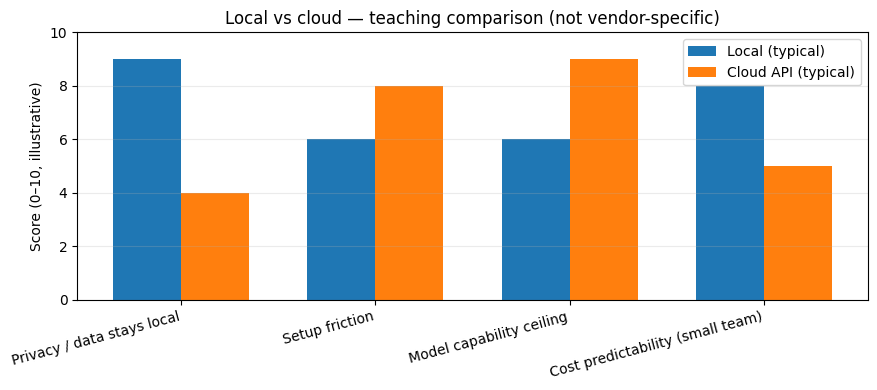

In [68]:
# Step 8 — Visual comparison (synthetic scores; no API key required)
# Uncomment once if matplotlib is missing:
# %pip install -q matplotlib
"""Higher = better for that criterion (subjective teaching defaults)."""

labels = ["Privacy / data stays local", "Setup friction", "Model capability ceiling", "Cost predictability (small team)"]
local_scores = [9, 6, 6, 8]
cloud_scores = [4, 8, 9, 5]

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None:
    print("차트용 matplotlib 설치:  %pip install -q matplotlib\n")
    w = 40
    for i, lab in enumerate(labels):
        print(lab)
        la = int(local_scores[i] * w / 10)
        ca = int(cloud_scores[i] * w / 10)
        print("  local ", "#" * la, f" {local_scores[i]}/10")
        print("  cloud ", "#" * ca, f" {cloud_scores[i]}/10")
        print()
else:
    x = range(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar([i - width / 2 for i in x], local_scores, width, label="Local (typical)")
    ax.bar([i + width / 2 for i in x], cloud_scores, width, label="Cloud API (typical)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylim(0, 10)
    ax.set_ylabel("Score (0–10, illustrative)")
    ax.set_title("Local vs cloud — teaching comparison (not vendor-specific)")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


In [69]:
def cloud_chat_demo() -> None:
    """Minimal OpenAI-compatible chat completion (optional)."""
    try:
        from pathlib import Path

        from dotenv import load_dotenv

        for env_dir in (Path.cwd(), Path.cwd().parent):
            env_path = env_dir / ".env"
            if env_path.is_file():
                load_dotenv(env_path)
                break
    except Exception:
        pass

    api_key = (os.environ.get("OPENAI_API_KEY") or "").strip()
    if not api_key:
        print(
            "건너뜀: 클라우드 데모를 실행하려면 환경 변수 OPENAI_API_KEY를 설정하세요.\n"
            "이 노트북의 주요 연습은 클라우드 접근이 필요하지 않습니다."
        )
        return

    base_url = (
        os.environ.get("OPENAI_BASE_URL") or "https://api.openai.com/v1"
    ).rstrip("/")
    model = (os.environ.get("OPENAI_MODEL") or "gpt-4o-mini").strip()

    system_prompt = "You help engineers write clear, cautious summaries."
    user_prompt = (
        "In 80 words, explain when cloud LLMs may be preferable to local LLMs "
        "for workplace tasks, mentioning privacy and cost."
    )

    model_l = model.lower()
    reasoning_model = model_l.startswith(("o1", "o3"))
    if reasoning_model:
        # o-series models reject system role and temperature.
        messages = [
            {
                "role": "user",
                "content": f"{system_prompt}\n\n{user_prompt}",
            }
        ]
    else:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]

    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    body: Dict[str, Any] = {"model": model, "messages": messages}
    if not reasoning_model:
        body["temperature"] = 0.2

    url = f"{base_url}/chat/completions"
    r = requests.post(url, headers=headers, json=body, timeout=120)
    if not r.ok:
        detail = r.text.strip()
        try:
            err = r.json().get("error", {})
            detail = err.get("message") or detail
        except Exception:
            pass
        print(
            f"클라우드 데모 실패 ({r.status_code} {r.reason}).\n"
            f"모델: {model!r} · URL: {url}\n"
            f"API 메시지: {detail}\n\n"
            "팁: OPENAI_API_KEY를 확인하고, 이 데모에는 OPENAI_MODEL=gpt-4o-mini를 사용하며, "
            "프록시가 아니면 OPENAI_BASE_URL=https://api.openai.com/v1을 설정하세요."
        )
        return

    data = r.json()
    text = data["choices"][0]["message"]["content"]
    display_llm_result(
        "Step 8 · Cloud API · Sample reply",
        text,
        subtitle=f"OpenAI-compatible · model {model}",
        explain="Cloud response—remember data left your runtime; review privacy policy.",
        show_reading_guide=False,
    )


cloud_chat_demo()

클라우드 데모 실패 (400 Bad Request).
모델: 'gpt-4o-mini #gemini-2.0-flash' · URL: https://api.openai.com/v1/chat/completions
API 메시지: invalid model ID

팁: OPENAI_API_KEY를 확인하고, 이 데모에는 OPENAI_MODEL=gpt-4o-mini를 사용하며, 프록시가 아니면 OPENAI_BASE_URL=https://api.openai.com/v1을 설정하세요.


### 클라우드 일러스트 — 동일 작업, 두 세계

| 측면 | 로컬(`llama_cpp` / Ollama / transformers / LM Studio) | Cloud API |
|--------|---------------------|-----------|
| 데이터 거주 | 설정 시 PC / 자체 서버에 유지 | 엔터프라이즈 통제 없으면 기기를 떠남 |
| 설정 | 가중치 + 런타임 설치 | API 키 + 과금 |
| 적합 | 민감 초안, 오프라인 야드, 반복 실험 | 최신 모델, 낮은 로컬 하드웨어 |

많은 팀이 초안은 **로컬**, 가장 어려운 추론은 **클라우드** — 정책이 허용할 때.


## Step 9 — 로컬 vs 클라우드: 빠른 의사결정 가이드

**로컬 우선** 상황:

- 문서가 기밀이거나 수출 통제 대상.
- 네트워크 불안정(조선소, 현장).
- 예측 가능한 오프라인 데모 필요.

**클라우드 고려** 상황:

- 최상급 다국어 또는 long-context 성능 필요.
- IT가 벤더와 데이터 처리 계약(DPA) 승인.
- 로컬 하드웨어가 필요 품질 수준을 못 돌림.

**하이브리드 워크플로(흔함):** 로컬에서 요약·익명화 → 허용 시 선택적 클라우드로 다듬기.


In [70]:
# Step 9 — Interactive decision helper (edit sliders 1–5; no LLM call)
"""1 = low / disagree, 5 = high / agree — tune to your project."""

scores = {
    "data_sensitivity": 4,  # confidential / export-controlled content?
    "offline_need": 3,  # must work without internet?
    "local_hardware": 2,  # can this PC/server run a good enough model?
    "need_best_model": 3,  # need frontier reasoning / multilingual?
    "vendor_approved": 2,  # IT + legal approved cloud vendor + DPA?
}

w_local = (
    scores["data_sensitivity"] * 1.2
    + scores["offline_need"] * 1.1
    + scores["local_hardware"] * 0.9
    - scores["need_best_model"] * 0.7
)
w_cloud = (
    scores["need_best_model"] * 1.3
    + scores["vendor_approved"] * 1.4
    - scores["data_sensitivity"] * 1.1
    - scores["offline_need"] * 0.9
)

print("가중 기울기(높을수록 신호가 강함):\n  local_support", round(w_local, 2), "\n  cloud_support", round(w_cloud, 2))

if w_local - w_cloud >= 0.8:
    rec = "LEAN LOCAL: prioritize on-device / private server LLMs; use cloud only for anonymized or approved workloads."
elif w_cloud - w_local >= 0.8:
    rec = "LEAN CLOUD: policy and connectivity allow; still scrub sensitive fields before sending."
else:
    rec = "HYBRID: draft/redact locally; optional cloud for polish or hardest tasks if approved."

print("\n권장:\n ", rec)

print("\n--- 입력값 ---")
for k, v in scores.items():
    print(f"  {k}: {v}/5")


가중 기울기(높을수록 신호가 강함):
  local_support 7.8 
  cloud_support -0.4

권장:
  LEAN LOCAL: prioritize on-device / private server LLMs; use cloud only for anonymized or approved workloads.

--- 입력값 ---
  data_sensitivity: 4/5
  offline_need: 3/5
  local_hardware: 2/5
  need_best_model: 3/5
  vendor_approved: 2/5


## Step 10 — 한계, 프라이버시, 안전한 사용

- **환각(Hallucinations):** 모델이 틀려도 자신 있게 들릴 수 있음 — 중요 수치 검증.
- **PII / 비밀:** 정책 승인 없이 비밀번호, 여권 전체 번호, 미공개 가격 붙여넣기 금지.
- **IP:** 고객 도면·선급 서신은 제한될 수 있음 — 회사 규정 준수.
- **안전 critical 시스템:** LLM 출력은 엔지니어링 서명 **대체 불가**.
- **편향 & 어조:** 외부 발송 전 문구 검토.

**마무리 제안:** *본인* 반복 업무에 맞는 프롬프트 템플릿 5–10개 라이브러리 유지 — 매월 다듬기.


In [71]:
# Step 10 — Printable pre-flight checklist (no LLM; copy to procedures if useful)
from datetime import date

checklist = f"""
## LLM use — pre-flight checklist ({date.today().isoformat()})

- [ ] **Data class:** Is this document OK to leave the device under company policy?
- [ ] **PII removed:** Names, IDs, exact pricing, hull numbers redacted unless allowed.
- [ ] **Safety / compliance:** No single-source LLM output for load-out, stability, or class submissions without review.
- [ ] **Verification plan:** Who signs off if numbers (torque, pressure, dates) matter?
- [ ] **Fallback:** What do we do if the model returns nonsense or DEMO MODE?
- [ ] **Retention:** Are we allowed to store this prompt/output in tickets/email archives?

**One-line purpose of this session:** ________________________________________________
"""

print(checklist)

# Optional LLM critique — set True after Step 4 + replace snippet below
RUN_OPTIONAL_LLM_CRITIQUE = False

SANITIZED_POLICY_SNIPPET = """
(Replace with a short anonymized policy paragraph you are allowed to process.)
""".strip()

if RUN_OPTIONAL_LLM_CRITIQUE:
    _fn = globals().get("call_llm")
    if _fn is None:
        print("먼저 Step 4를 실행하세요(call_llm 정의).")
    elif "Replace with" in SANITIZED_POLICY_SNIPPET:
        print("RUN_OPTIONAL_LLM_CRITIQUE를 켜기 전에 SANITIZED_POLICY_SNIPPET을 수정하세요.")
    else:
        critique = _fn(
            "List 5 concrete risks if teams rely on LLMs for this kind of content without governance. Bullet points only.\n\nTEXT:\n"
            + SANITIZED_POLICY_SNIPPET,
            system="Do not invent company names or laws.",
            temperature=0.1,
        )
        print("\n--- 선택 모델 비평 ---\n")
        print(critique)



## LLM use — pre-flight checklist (2026-06-18)

- [ ] **Data class:** Is this document OK to leave the device under company policy?
- [ ] **PII removed:** Names, IDs, exact pricing, hull numbers redacted unless allowed.
- [ ] **Safety / compliance:** No single-source LLM output for load-out, stability, or class submissions without review.
- [ ] **Verification plan:** Who signs off if numbers (torque, pressure, dates) matter?
- [ ] **Fallback:** What do we do if the model returns nonsense or DEMO MODE?
- [ ] **Retention:** Are we allowed to store this prompt/output in tickets/email archives?

**One-line purpose of this session:** ________________________________________________



## 부록 A — Google Colab에서 **Ollama** 실행(선택)

Colab 런타임은 **Linux x86_64**이므로 공식 **Ollama** Linux 빌드를 **동일 VM**에 설치하고 `http://127.0.0.1:11434`로 호출할 수 있습니다. **실험적**으로 취급: 세션 끊김, 디스크 초기화, 무료 **RAM/GPU** 제한.

**1. 설치**(새 런타임마다 한 번):

```bash
curl -fsSL https://ollama.com/install.sh | sh
```

**2. 백그라운드에서 데몬 시작**(안 하면 명령이 멈춤):

```bash
nohup ollama serve > /tmp/ollama.log 2>&1 &
sleep 3
```

**3. 모델 pull**(무료 Colab RAM이 빡빡 — 불확실하면 작은 pull):

```bash
ollama pull llama3.2
```

(**OOM** / timeout 시 폴백: `ollama pull tinyllama` 및 아래 Python 예제에서 `"model": "tinyllama"` 설정.)


**4. Python에서 호출**(동일 노트북):

```python
import requests
r = requests.post(
    "http://127.0.0.1:11434/api/generate",
    json={"model": "llama3.2", "prompt": "Say hello in one sentence.", "stream": False},
    timeout=120,
)
print(r.json().get("response", ""))
```

**한계:** 임시 VM, 큰 모델 **OOM** 가능, GPU 동작은 런타임마다 다름. 메인 노트북 경로는 **`llama-cpp-python` + GGUF**(Step 0b / Step 4)로 Ollama 데몬 불필요. 위 스니펫은 **`LLM_BACKEND=ollama`** 전용.

**Colab 대안:** 기본 **`LLM_BACKEND=llama_cpp`**(Step 0–4), 또는 `llama-cpp-python` wheel 설치 실패 시 **`LLM_BACKEND=transformers`**.


## 부록 B — 강사 노트(선택)

- **시간:** 90–150분: Step 1–4c(시나리오 선택) + **Step 5–7**; Step 8 차트 + 선택 클라우드 API는 데모/숙제; Step 9–10은 토론 + 간단 설문.
- **모델:** **기본 경로:** **`llama-cpp-python`** + Hugging Face **GGUF**(Step 0b). 선택: **`LLM_BACKEND=ollama`**, 또는 **`TRANSFORMERS_MODEL_ID`**(예: TinyLlama 또는 gated Llama + `HF_TOKEN`).
- **GPU 실습:** CUDA + `device_map=auto`가 큰 모델에 도움; CPU만 클래스는 TinyLlama 또는 작은 instruct 모델 유지.
- **평가:** 학습자에게 실제(익명화) 단락 하나를 가져와 프롬프트 두 번 반복 개선하게 하기.
